# Load Packages

In [177]:
# ==============================
# Install required packages
# ==============================
!pip install -q --upgrade pip
!pip install -q pyunpack patool rarfile rioxarray rasterio xarray

# ==============================
# Standard library
# ==============================
import os
import sys
import glob
import pathlib
import zipfile

# ==============================
# General utilities
# ==============================
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# Image handling
# ==============================
import PIL
from PIL import Image

# ==============================
# Raster / geospatial
# ==============================
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.windows import Window
import rioxarray as rxr

# ==============================
# Archive handling
# ==============================
import pyunpack
from rarfile import RarFile

# ==============================
# TensorFlow / Keras
# ==============================
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, Conv2DTranspose, MaxPooling2D,
    UpSampling2D, Dropout, BatchNormalization,
    Activation, concatenate, add, multiply
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

# ==============================
# Evaluation metrics
# ==============================
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix
)


In [178]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [179]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [180]:
# Specify whether to download data or read in
download = True
base_dir = "./content/Iraq_Marshes_s2_water_seg/"

In [181]:
# Download data
if download:
    url = 'https://zenodo.org/records/18601207/files/Iraq_Marshes_s2_water_seg.zip?download=1'

    # download
    r = requests.get(url)
    with open("data.zip", "wb") as f:
      f.write(r.content)

    # extract
    with zipfile.ZipFile("data.zip", "r") as z:
      z.extractall("/content/")

    # confirm
    os.listdir("/content/")

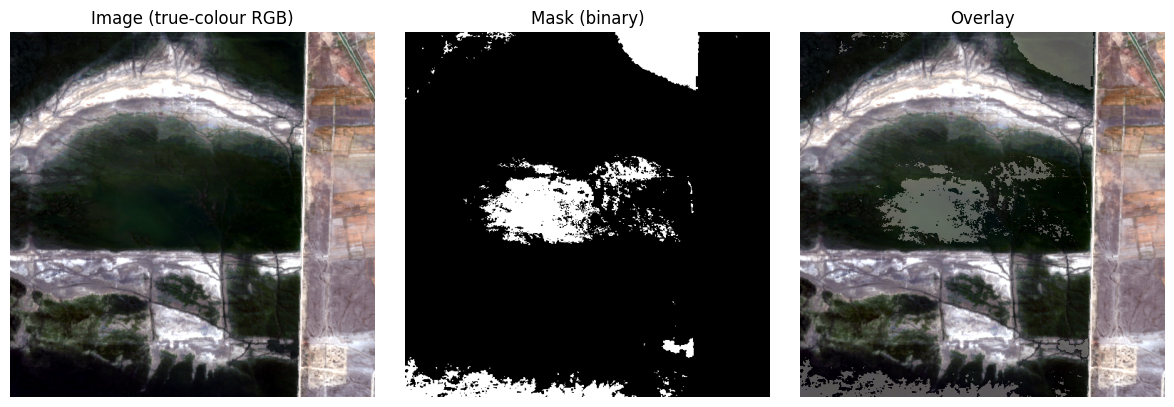

Image shape: (512, 512, 4) dtype: float32
Mask shape: (512, 512) dtype: uint8 mask min/max: 0 1
Water pixel ratio: 0.10550308227539062


In [182]:
fname = "central_marshes_2021_r004_c009.npy"
base_dir = "/content/Iraq_Marshes_s2_water_seg/"
split = "training"
# =========================
# 2) LOAD ONE TILE
# =========================

img_path  = os.path.join(base_dir, split, "images", fname)
mask_path = os.path.join(base_dir, split, "masks",  fname)

img  = np.load(img_path).astype(np.float32)  # (H,W,4)
mask = np.load(mask_path)

# masks might be (H,W,1)
if mask.ndim == 3 and mask.shape[-1] == 1:
    mask = mask[..., 0]

# =========================
# 3) MAKE TRUE-COLOUR RGB (B4,B3,B2) + PER-CHANNEL STRETCH
# =========================
# Assuming band order is [B2,B3,B4,B8] -> RGB = [B4,B3,B2] = indices [2,1,0]
rgb = img[..., [2, 1, 0]]

rgb_disp = np.zeros_like(rgb, dtype=np.float32)
for c in range(3):
    p2, p98 = np.percentile(rgb[..., c], (2, 98))
    rgb_disp[..., c] = np.clip((rgb[..., c] - p2) / (p98 - p2 + 1e-6), 0, 1)

# =========================
# 4) MASK -> BINARY
# =========================
m = mask.astype(np.float32)
if m.max() > 1.5:  # e.g., 0/255
    m = m / 255.0
m_bin = (m > 0.5).astype(np.uint8)

# =========================
# 5) PLOT
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb_disp)
plt.title("Image (true-colour RGB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(m_bin, cmap="gray")
plt.title("Mask (binary)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rgb_disp)
plt.imshow(np.ma.masked_where(m_bin == 0, m_bin), cmap="Reds", alpha=0.35)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", img.shape, "dtype:", img.dtype)
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "mask min/max:", mask.min(), mask.max())
print("Water pixel ratio:", float(m_bin.mean()))

# Functions

In [183]:
'''
  Returns an image plot of mask prediction
'''

def reconstruct_image(model, image, rounded=False):

  # Find model prediction
  reconstruction = model.predict(image).reshape(image.shape[1], image.shape[2])
  # Standardise between 0-1
  reconstruction = reconstruction/np.max(reconstruction)

  # Round to 0-1, binary pixel-by-pixel classification
  if rounded:
    reconstruction = np.round(reconstruction)

  # Plot reconstructed mask (prediction)
  plt.imshow(reconstruction)

In [184]:
'''
  Returns array of mask prediction, given model and image
'''
def reconstruct_array(model, image, rounded=False):

  # Find model prediction
  reconstruction = model.predict(image).reshape(image.shape[1], image.shape[2])

  if rounded:
    reconstruction = np.round(reconstruction)

  return reconstruction # Returns array

In [185]:
def score_eval2(model, image, mask):
    """Gives score of mask vs prediction"""
    if type(image) != list:
        # Check if we have multiple images
        if image.shape[0] > 1:
            # Evaluate each image separately to get per-image scores
            scores = []
            for i in range(image.shape[0]):
                reconstruction = model.predict(np.expand_dims(image[i], axis=0), verbose=0)
                reconstruction = reconstruction.reshape(reconstruction.shape[1], reconstruction.shape[2])
                reconstruction = np.round(reconstruction).flatten()
                scores.append(accuracy_score(mask[i].flatten(), reconstruction))
            return scores  # Return list of scores for std calculation
        else:
            # Single image (1, 512, 512, channels)
            reconstruction = model.predict(image, verbose=0)
            reconstruction = reconstruction.reshape(reconstruction.shape[1], reconstruction.shape[2])
            reconstruction = np.round(reconstruction).flatten()
            return accuracy_score(mask.flatten(), reconstruction)
    else:
        # If a list of images input, find accuracy for each
        scores = []
        for i in range(len(image)):
            reconstruction = model.predict(np.expand_dims(image[i], axis=0), verbose=0)
            reconstruction = np.round(reconstruction).flatten()
            scores.append(accuracy_score(mask[i].flatten(), reconstruction))
        return scores


def recall_eval(model, image, mask):
    """Find recall score"""
    if type(image) != list:
        # Check if we have multiple images
        if image.shape[0] > 1:
            # Evaluate each image separately
            recalls = []
            for i in range(image.shape[0]):
                reconstruction = model.predict(np.expand_dims(image[i], axis=0), verbose=0)
                reconstruction = reconstruction.reshape(reconstruction.shape[1], reconstruction.shape[2])
                reconstruction = np.round(reconstruction).flatten()
                recalls.append(recall_score(mask[i].flatten(), reconstruction, average='weighted', zero_division=0))
            return recalls  # Return list for std calculation
        else:
            # Single image
            reconstruction = model.predict(image, verbose=0)
            reconstruction = reconstruction.reshape(reconstruction.shape[1], reconstruction.shape[2])
            reconstruction = np.round(reconstruction).flatten()
            return recall_score(mask.flatten(), reconstruction, average='weighted', zero_division=0)
    else:
        # If a list of images input, find recall for each
        recalls = []
        for i in range(len(image)):
            reconstruction = model.predict(np.expand_dims(image[i], axis=0), verbose=0)
            reconstruction = reconstruction.reshape(reconstruction.shape[1], reconstruction.shape[2])
            reconstruction = np.round(reconstruction).flatten()
            recalls.append(recall_score(mask[i].flatten(), reconstruction, average='weighted', zero_division=0))
        return recalls


def precision_eval(model, image, mask):
    """Find precision score"""
    if type(image) != list:
        # Check if we have multiple images
        if image.shape[0] > 1:
            # Evaluate each image separately
            precisions = []
            for i in range(image.shape[0]):
                reconstruction = model.predict(np.expand_dims(image[i], axis=0), verbose=0)
                reconstruction = reconstruction.reshape(reconstruction.shape[1], reconstruction.shape[2])
                reconstruction = np.round(reconstruction).flatten()
                precisions.append(precision_score(mask[i].flatten(), reconstruction, average='weighted', zero_division=0))
            return precisions  # Return list for std calculation
        else:
            # Single image
            reconstruction = model.predict(image, verbose=0)
            reconstruction = reconstruction.reshape(reconstruction.shape[1], reconstruction.shape[2])
            reconstruction = np.round(reconstruction).flatten()
            return precision_score(mask.flatten(), reconstruction, average='weighted', zero_division=0)
    else:
        # If a list of images input, find precision for each
        precisions = []
        for i in range(len(image)):
            reconstruction = model.predict(np.expand_dims(image[i], axis=0), verbose=0)
            reconstruction = reconstruction.reshape(reconstruction.shape[1], reconstruction.shape[2])
            reconstruction = np.round(reconstruction).flatten()
            precisions.append(precision_score(mask[i].flatten(), reconstruction, average='weighted', zero_division=0))
        return precisions

# Ingest and Process RGB Dataset

In [186]:

# ==============================================================================
# INGEST IMAGES
# ==============================================================================

## Training images
training_images_list = os.listdir(f"{base_dir}training/images/")
training_masks_list = []
training_images = []

for n in training_images_list:
    a = np.load(f"{base_dir}training/images/{n}")

    # Extract only RGB channels (first 3 bands)
    if a.ndim == 3 and a.shape[-1] > 3:
        a = a[:, :, :3]

    training_images.append(a)
    training_masks_list.append(n)  # Same filename for mask

## Training masks
training_masks = []
for n in training_masks_list:
    a = np.load(f"{base_dir}training/masks/{n}")
    training_masks.append(a)

## Test images
test_images_list = os.listdir(f"{base_dir}test/images/")
test_images = []
for n in test_images_list:
    a = np.load(f"{base_dir}test/images/{n}")

    # Extract only RGB channels (first 3 bands)
    if a.ndim == 3 and a.shape[-1] > 3:
        a = a[:, :, :3]

    test_images.append(a)

## Test masks
test_masks_list = []
test_masks = []
for n in test_images_list:
    test_masks_list.append(n)

for n in test_masks_list:
    a = np.load(f"{base_dir}test/masks/{n}")
    test_masks.append(a)

## Validation images
validation_images_list = os.listdir(f"{base_dir}validation/images/")
validation_masks_list = []
validation_images = []

for n in validation_images_list:
    a = np.load(f"{base_dir}validation/images/{n}")

    # Extract only RGB channels (first 3 bands)
    if a.ndim == 3 and a.shape[-1] > 3:
        a = a[:, :, :3]

    validation_images.append(a)
    validation_masks_list.append(n)  # Same filename for mask

## Validation masks
validation_masks = []
for n in validation_masks_list:
    a = np.load(f"{base_dir}validation/masks/{n}")
    validation_masks.append(a)

print(f"Loaded:")
print(f"Training: {len(training_images)} images, {len(training_masks)} masks")
print(f"Validation: {len(validation_images)} images, {len(validation_masks)} masks")
print(f"Test: {len(test_images)} images, {len(test_masks)} masks")
print(f"\nShapes:")
print(f"Training image: {training_images[0].shape}")
print(f"Training mask: {training_masks[0].shape}")

Loaded:
Training: 143 images, 143 masks
Validation: 99 images, 99 masks
Test: 20 images, 20 masks

Shapes:
Training image: (512, 512, 3)
Training mask: (512, 512, 1)



Preprocessing training data...


/tmp/ipython-input-3228717862.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr_uint8, mode="RGB")


Preprocessing validation data...
Preprocessing test data...

PREPROCESSED ARRAYS:
X_train: (143, 512, 512, 3) float32 range: [0.000, 1.000]
Y_train: (143, 512, 512, 1) uint8 unique: [0 1]
X_val  : (99, 512, 512, 3) float32 range: [0.000, 1.000]
Y_val  : (99, 512, 512, 1) uint8 unique: [0 1]
X_test : (20, 512, 512, 3) float32 range: [0.000, 1.000]
Y_test : (20, 512, 512, 1) uint8 unique: [0 1]


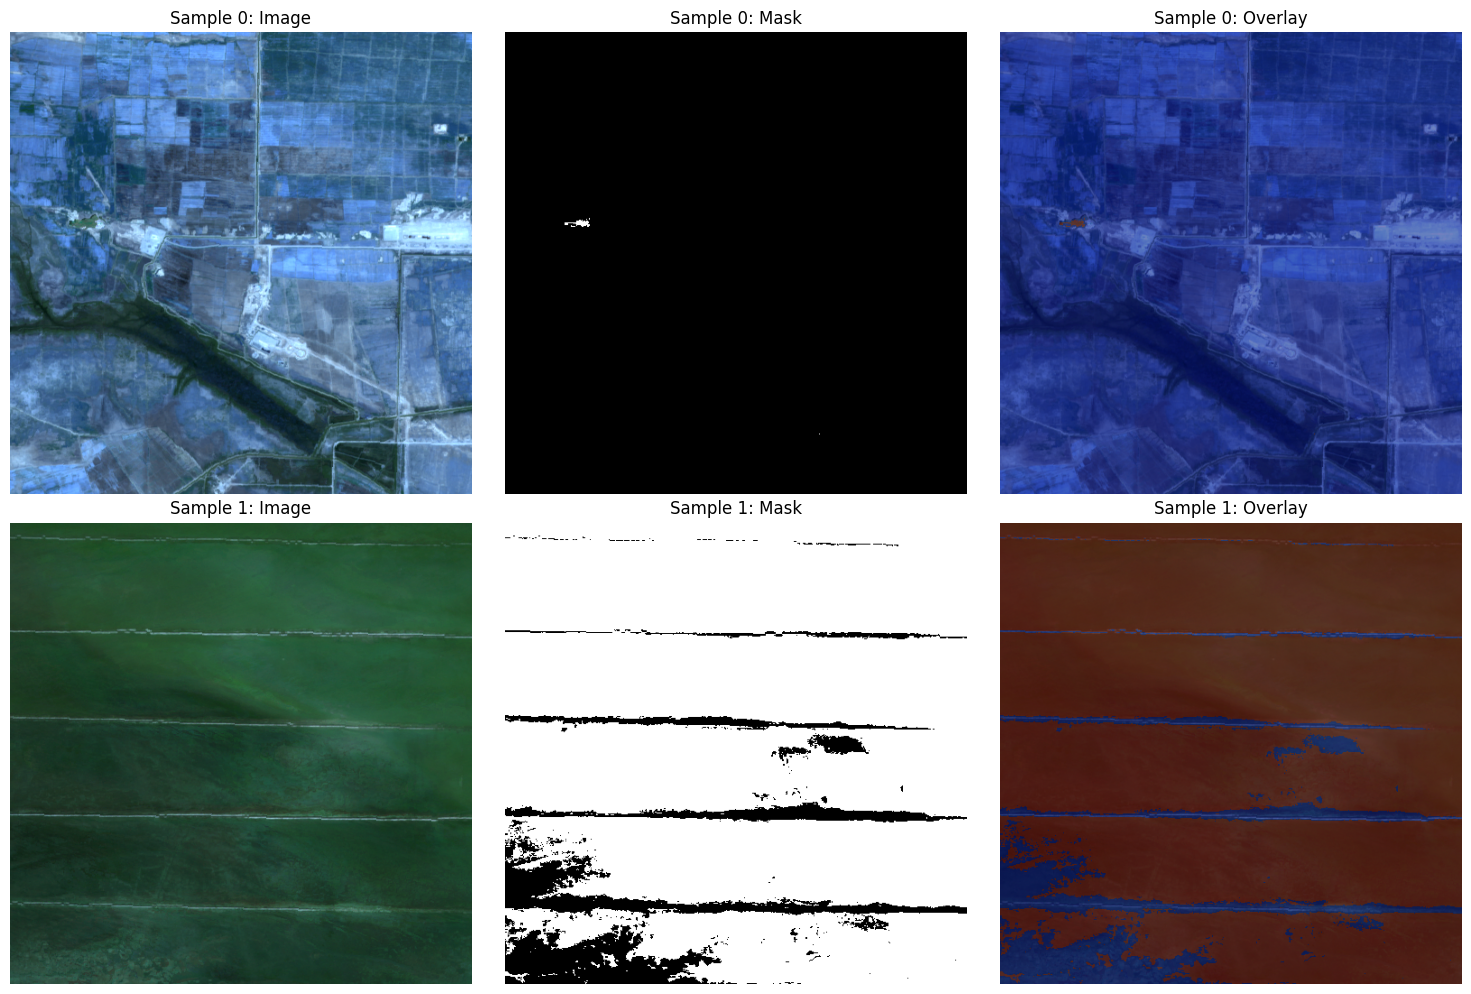


Mask value check:
Unique values in mask: [0 1]
Percentage of water (value=1): 0.04%
Percentage of non-water (value=0): 99.96%


In [187]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

IMG_SIZE = 512

def preprocess_img_npy(img_array, size=IMG_SIZE):
    """Preprocess numpy array image to RGB float32."""
    arr = img_array.copy()

    # Already RGB from loading step, but verify
    if arr.ndim == 3 and arr.shape[-1] > 3:
        arr = arr[..., :3]

    # Determine value range and normalize
    if arr.max() > 1.0:
        # Assume 0-255 or 0-10000 range
        arr = arr.astype(np.float32) / arr.max()
    else:
        # Already in 0-1 range
        arr = arr.astype(np.float32)

    # Convert to uint8 for PIL
    arr_uint8 = (arr * 255.0).clip(0, 255).astype(np.uint8)

    # Resize using PIL
    img = Image.fromarray(arr_uint8, mode="RGB")
    img = img.resize((size, size), resample=Image.BILINEAR)

    # Convert back to float32 [0, 1]
    return np.asarray(img, dtype=np.float32) / 255.0

def preprocess_mask_npy(mask_array, size=IMG_SIZE):
    """Preprocess numpy array mask to binary uint8."""
    y = mask_array.copy()

    # Handle multi-dimensional masks
    if y.ndim == 3:
        y = y[..., 0]  # Take first channel

    # Binarize
    y = (y > 0).astype(np.uint8)

    # Resize if needed
    if y.shape[0] != size or y.shape[1] != size:
        y_img = Image.fromarray(y)
        y_img = y_img.resize((size, size), resample=Image.NEAREST)
        y = np.asarray(y_img, dtype=np.uint8)

    return y  # Return (512, 512) - NO extra dimension yet

# Apply preprocessing
print("\nPreprocessing training data...")
training_images_processed = [preprocess_img_npy(im) for im in training_images]
training_masks_processed = [preprocess_mask_npy(m) for m in training_masks]

print("Preprocessing validation data...")
validation_images_processed = [preprocess_img_npy(im) for im in validation_images]
validation_masks_processed = [preprocess_mask_npy(m) for m in validation_masks]

print("Preprocessing test data...")
test_images_processed = [preprocess_img_npy(im) for im in test_images]
test_masks_processed = [preprocess_mask_npy(m) for m in test_masks]

# Stack into simple arrays (no transpose, no reshape)
X_train = np.array(training_images_processed, dtype=np.float32)  # (N, 512, 512, 3)
Y_train = np.array(training_masks_processed, dtype=np.uint8)     # (N, 512, 512)
Y_train = Y_train[..., np.newaxis]  # Add channel: (N, 512, 512, 1)

X_val = np.array(validation_images_processed, dtype=np.float32)
Y_val = np.array(validation_masks_processed, dtype=np.uint8)
Y_val = Y_val[..., np.newaxis]

X_test = np.array(test_images_processed, dtype=np.float32)
Y_test = np.array(test_masks_processed, dtype=np.uint8)
Y_test = Y_test[..., np.newaxis]

# ==============================================================================
# DISPLAY RESULTS
# ==============================================================================

print("\n" + "="*60)
print("PREPROCESSED ARRAYS:")
print("="*60)
print(f"X_train: {X_train.shape} {X_train.dtype} range: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"Y_train: {Y_train.shape} {Y_train.dtype} unique: {np.unique(Y_train)}")
print(f"X_val  : {X_val.shape} {X_val.dtype} range: [{X_val.min():.3f}, {X_val.max():.3f}]")
print(f"Y_val  : {Y_val.shape} {Y_val.dtype} unique: {np.unique(Y_val)}")
print(f"X_test : {X_test.shape} {X_test.dtype} range: [{X_test.min():.3f}, {X_test.max():.3f}]")
print(f"Y_test : {Y_test.shape} {Y_test.dtype} unique: {np.unique(Y_test)}")
print("="*60)

# Visualize samples
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i in range(2):
    idx = i

    # Now shapes are clean: X_train[idx] is (512, 512, 3), Y_train[idx] is (512, 512, 1)
    img_display = X_train[idx]
    mask_display = Y_train[idx, :, :, 0]

    # Original image
    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title(f'Sample {idx}: Image')
    axes[i, 0].axis('off')

    # Mask
    axes[i, 1].imshow(mask_display, cmap='gray')
    axes[i, 1].set_title(f'Sample {idx}: Mask')
    axes[i, 1].axis('off')

    # Overlay
    axes[i, 2].imshow(img_display)
    axes[i, 2].imshow(mask_display, cmap='jet', alpha=0.5)
    axes[i, 2].set_title(f'Sample {idx}: Overlay')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# Check mask values
print("\nMask value check:")
sample_mask = Y_train[0, :, :, 0]
print(f"Unique values in mask: {np.unique(sample_mask)}")
print(f"Percentage of water (value=1): {100 * np.sum(sample_mask == 1) / sample_mask.size:.2f}%")
print(f"Percentage of non-water (value=0): {100 * np.sum(sample_mask == 0) / sample_mask.size:.2f}%")

In [188]:
print("Train image:", np.array(training_images[0]).shape)
print("Train mask :", np.array(training_masks[0]).shape, np.unique(training_masks[0])[:10])


Train image: (512, 512, 3)
Train mask : (512, 512, 1) [0 1]


In [189]:
# Create TensorFlow dataset from validation arrays
validation_df = tf.data.Dataset.from_tensor_slices((X_val, Y_val))
validation_df = validation_df.batch(1)  # ← CRITICAL: Add batching to match training


In [190]:

def adjustData(img, mask, num_class):
    mask[mask > 0.5] = 1  # WATER
    mask[mask <= 0.5] = 0  # NON-WATER
    return (img, mask)

def trainGenerator(batch_size,
                   image_array,
                   mask_array,
                   aug_dict,
                   image_save_prefix="image",
                   mask_save_prefix="mask",
                   num_class=2,
                   save_to_dir=None,
                   target_size=(512, 512),
                   seed=1):

    image_datagen = ImageDataGenerator(**aug_dict)
    mask_datagen = ImageDataGenerator(**aug_dict)

    image_generator = image_datagen.flow(image_array,
                                         batch_size=batch_size,
                                         save_to_dir=save_to_dir,
                                         save_prefix=image_save_prefix,
                                         seed=seed)

    mask_generator = mask_datagen.flow(mask_array,
                                       batch_size=batch_size,
                                       save_to_dir=save_to_dir,
                                       save_prefix=mask_save_prefix,
                                       seed=seed)

    train_generator = zip(image_generator, mask_generator)

    for (img, mask) in train_generator:
        img, mask = adjustData(img, mask, num_class)
        yield (img, mask)


In [191]:

# ==============================================================================
# DATA AUGMENTATION PARAMETERS
# ==============================================================================

# Training augmentation (with transformations)
data_gen_args = dict(rotation_range=180,
                     width_shift_range=0.25,
                     height_shift_range=0.25,
                     shear_range=0.25,
                     zoom_range=0.25,
                     horizontal_flip=True,
                     vertical_flip=True,
                     fill_mode='reflect')

# Validation augmentation (NO transformations)
validation_gen_args = dict()

# ==============================================================================
# CREATE GENERATORS - Use your preprocessed arrays directly
# ==============================================================================

# Training generator with augmentation
train = trainGenerator(1, X_train, Y_train, data_gen_args, save_to_dir=None)

# Validation generator without augmentation
validation_gen = trainGenerator(1, X_val, Y_val, validation_gen_args, save_to_dir=None)

# Ingest and Process 4-band Datasets

## 4-band Marshes dataset

In [192]:
base_dir2 = r"./content/Iraq_Marshes_s2_water_seg/"

In [193]:
base_dir2 = "/content/Iraq_Marshes_s2_water_seg/"

# Ingest images and normalize
def minmax_norm(a, eps=1e-8):
    """Per-image min-max normalization to [0, 1]."""
    a = a.astype(np.float32)
    amin = np.min(a)
    amax = np.max(a)
    return (a - amin) / (amax - amin + eps)

def ensure_mask_hw1(m):
    """Ensure mask is (H, W, 1) shape."""
    m = np.array(m)
    # squeeze common odd shapes
    if m.ndim == 3 and m.shape[-1] == 1:
        return m.astype(np.int32)
    if m.ndim == 3 and m.shape[0] == 1:
        m = m[0]
    if m.ndim == 2:
        m = m[..., None]
    return m.astype(np.int32)

def only_npy(files):
    """Filter for .npy files only."""
    return [f for f in files if f.lower().endswith(".npy")]

# =========================
# TRAIN (4-band)
# =========================
train_img_dir2  = os.path.join(base_dir2, "training", "images")
train_mask_dir2 = os.path.join(base_dir2, "training", "masks")

training_images_list2 = only_npy(os.listdir(train_img_dir2))[:250]
training_masks_list2 = []
training_images2 = []

for n in training_images_list2:
    training_masks_list2.append(n)  # Same filename for mask

    # Load image (H, W, 4) - rasterio format is (bands, H, W), np.load is (H, W, bands)
    a = np.load(os.path.join(train_img_dir2, n))
    a = minmax_norm(a)  # Normalize to [0, 1]
    training_images2.append(a)

## Training masks
training_masks2 = []
for n in training_masks_list2:
    a = np.load(os.path.join(train_mask_dir2, n))
    training_masks2.append(ensure_mask_hw1(a))

# =========================
# TEST (4-band)
# =========================
test_img_dir2  = os.path.join(base_dir2, "test", "images")
test_mask_dir2 = os.path.join(base_dir2, "test", "masks")

test_images_list2 = only_npy(os.listdir(test_img_dir2))
test_masks_list2 = []
test_images2 = []

for n in test_images_list2:
    test_masks_list2.append(n)

    a = np.load(os.path.join(test_img_dir2, n))
    a = minmax_norm(a)
    test_images2.append(a)

## Test masks
test_masks2 = []
for n in test_masks_list2:
    a = np.load(os.path.join(test_mask_dir2, n))
    test_masks2.append(ensure_mask_hw1(a))

# =========================
# VALIDATION (4-band)
# =========================
val_img_dir2  = os.path.join(base_dir2, "validation", "images")
val_mask_dir2 = os.path.join(base_dir2, "validation", "masks")

validation_images_list2 = only_npy(os.listdir(val_img_dir2))
validation_masks_list2 = []
validation_images2 = []

for n in validation_images_list2:
    validation_masks_list2.append(n)

    a = np.load(os.path.join(val_img_dir2, n))
    a = minmax_norm(a)
    validation_images2.append(a)

## Validation masks
validation_masks2 = []
for n in validation_masks_list2:
    a = np.load(os.path.join(val_mask_dir2, n))
    validation_masks2.append(ensure_mask_hw1(a))

# =========================
# Verify
# =========================
print("Loaded:")
print(f"Training: {len(training_images2)} images, {len(training_masks2)} masks")
print(f"Validation: {len(validation_images2)} images, {len(validation_masks2)} masks")
print(f"Test: {len(test_images2)} images, {len(test_masks2)} masks")

print(f"\nShapes:")
print(f"Training image: {training_images2[0].shape} dtype: {training_images2[0].dtype}")
print(f"Training mask: {training_masks2[0].shape} dtype: {training_masks2[0].dtype}")

print(f"\nValue ranges:")
print(f"Image range: [{training_images2[0].min():.3f}, {training_images2[0].max():.3f}]")
print(f"Mask unique: {np.unique(training_masks2[0])}")

Loaded:
Training: 143 images, 143 masks
Validation: 99 images, 99 masks
Test: 20 images, 20 masks

Shapes:
Training image: (512, 512, 4) dtype: float32
Training mask: (512, 512, 1) dtype: int32

Value ranges:
Image range: [0.000, 1.000]
Mask unique: [0 1]


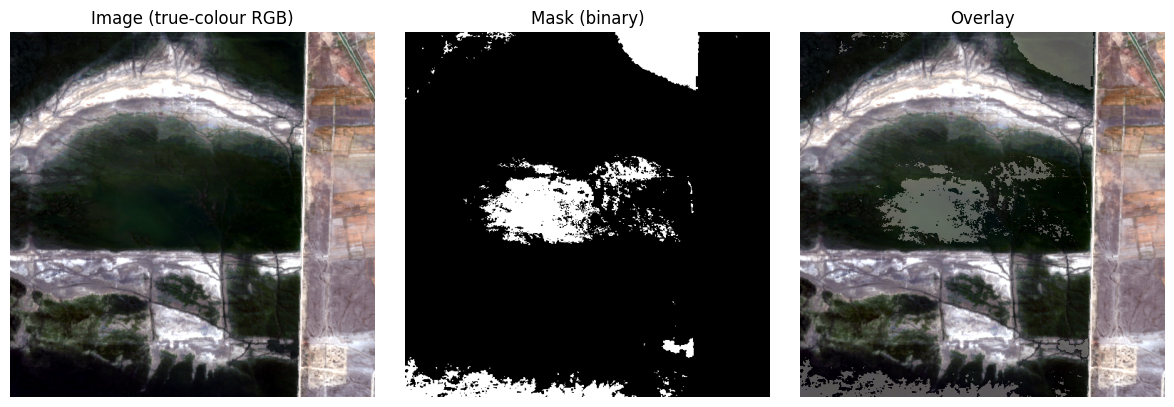

Image shape: (512, 512, 4) dtype: float32
Mask shape: (512, 512) dtype: uint8 mask min/max: 0 1
Water pixel ratio: 0.10550308227539062


In [194]:
fname = "central_marshes_2021_r004_c009.npy"
base_dir = "/content/Iraq_Marshes_s2_water_seg"
split = "training"
# =========================
# 2) LOAD ONE TILE
# =========================

img_path  = os.path.join(base_dir, split, "images", fname)
mask_path = os.path.join(base_dir, split, "masks",  fname)

img  = np.load(img_path).astype(np.float32)  # (H,W,4)
mask = np.load(mask_path)

# masks might be (H,W,1)
if mask.ndim == 3 and mask.shape[-1] == 1:
    mask = mask[..., 0]

# =========================
# 3) MAKE TRUE-COLOUR RGB (B4,B3,B2) + PER-CHANNEL STRETCH
# =========================
# Assuming band order is [B2,B3,B4,B8] -> RGB = [B4,B3,B2] = indices [2,1,0]
rgb = img[..., [2, 1, 0]]

rgb_disp = np.zeros_like(rgb, dtype=np.float32)
for c in range(3):
    p2, p98 = np.percentile(rgb[..., c], (2, 98))
    rgb_disp[..., c] = np.clip((rgb[..., c] - p2) / (p98 - p2 + 1e-6), 0, 1)

# =========================
# 4) MASK -> BINARY
# =========================
m = mask.astype(np.float32)
if m.max() > 1.5:  # e.g., 0/255
    m = m / 255.0
m_bin = (m > 0.5).astype(np.uint8)

# =========================
# 5) PLOT
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb_disp)
plt.title("Image (true-colour RGB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(m_bin, cmap="gray")
plt.title("Mask (binary)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rgb_disp)
plt.imshow(np.ma.masked_where(m_bin == 0, m_bin), cmap="Reds", alpha=0.35)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", img.shape, "dtype:", img.dtype)
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "mask min/max:", mask.min(), mask.max())
print("Water pixel ratio:", float(m_bin.mean()))

In [195]:
# =========================
# PRE-PROCESS DATA: NO TRANSPOSE
# =========================

# Images: just ensure float32, no transpose
for i in range(len(training_images2)):
    training_images2[i] = training_images2[i].astype('float32')

for i in range(len(validation_images2)):
    validation_images2[i] = validation_images2[i].astype('float32')

for i in range(len(test_images2)):
    test_images2[i] = test_images2[i].astype('float32')

# Masks: ensure correct shape (512, 512, 1), no transpose
for i in range(len(training_masks2)):
    if training_masks2[i].ndim == 2:
        training_masks2[i] = training_masks2[i][..., np.newaxis]

for i in range(len(validation_masks2)):
    if validation_masks2[i].ndim == 2:
        validation_masks2[i] = validation_masks2[i][..., np.newaxis]

for i in range(len(test_masks2)):
    if test_masks2[i].ndim == 2:
        test_masks2[i] = test_masks2[i][..., np.newaxis]

# Convert to numpy arrays
training_images2 = np.array(training_images2, dtype=np.float32)
training_masks2 = np.array(training_masks2, dtype=np.uint8)

validation_images2 = np.array(validation_images2, dtype=np.float32)
validation_masks2 = np.array(validation_masks2, dtype=np.uint8)

test_images2 = np.array(test_images2, dtype=np.float32)
test_masks2 = np.array(test_masks2, dtype=np.uint8)

# =========================
# VERIFY FINAL SHAPES
# =========================

print("\n" + "="*60)
print("AFTER PREPROCESSING:")
print("="*60)
print(f"Training images shape: {training_images2.shape}")  # Should be (N, 512, 512, 4)
print(f"Training masks shape: {training_masks2.shape}")    # Should be (N, 512, 512, 1)
print(f"Validation images shape: {validation_images2.shape}")
print(f"Validation masks shape: {validation_masks2.shape}")
print(f"Test images shape: {test_images2.shape}")
print(f"Test masks shape: {test_masks2.shape}")
print("="*60)


AFTER PREPROCESSING:
Training images shape: (143, 512, 512, 4)
Training masks shape: (143, 512, 512, 1)
Validation images shape: (99, 512, 512, 4)
Validation masks shape: (99, 512, 512, 1)
Test images shape: (20, 512, 512, 4)
Test masks shape: (20, 512, 512, 1)


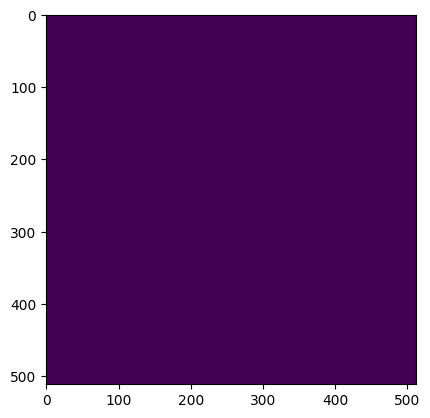

In [196]:
# Plot example training image first band
plt.imshow(training_images2[4].reshape(512,512,4)[:,:,0])

In [197]:
# Create TensorFlow datasets for training and validation sets
train_df_4band_marshes = tf.data.Dataset.from_tensor_slices((training_images2[0:250], training_masks2[0:250]))
train_df_4band_marshes = train_df_4band_marshes.batch(1)

validation_df_4band_marshes = tf.data.Dataset.from_tensor_slices((validation_images2, validation_masks2))
validation_df_4band_marshes = validation_df_4band_marshes.batch(1)

## 4-band Lake dataset

In [198]:
# Specify whether to download data or read in
download = True
base_dir3 = "/content/Iraq_Lake_s2_water_seg/"

In [199]:
# Download data (Atlantic Forest)
if download:
    # Download data
    url = "https://zenodo.org/records/18601352/files/Iraq_Lake_s2_water_seg.zip?download=1"

    # download
    r = requests.get(url)
    with open("data.zip", "wb") as f:
        f.write(r.content)

    # extract
    with zipfile.ZipFile("data.zip", "r") as z:
        z.extractall("/content/")

    # confirm
    os.listdir("/content/")


In [200]:
# Ingest images and normalize
def minmax_norm(a, eps=1e-8):
    """Per-image min-max normalization to [0, 1]."""
    a = a.astype(np.float32)
    amin = np.min(a)
    amax = np.max(a)
    return (a - amin) / (amax - amin + eps)

def ensure_mask_hw1(m):
    """Ensure mask is (H, W, 1) shape."""
    m = np.array(m)
    # squeeze common odd shapes
    if m.ndim == 3 and m.shape[-1] == 1:
        return m.astype(np.int32)
    if m.ndim == 3 and m.shape[0] == 1:
        m = m[0]
    if m.ndim == 2:
        m = m[..., None]
    return m.astype(np.int32)

def only_npy(files):
    """Filter for .npy files only."""
    return [f for f in files if f.lower().endswith(".npy")]

# =========================
# TRAIN (4-band)
# =========================
train_img_dir3  = os.path.join(base_dir3, "training", "images")
train_mask_dir3 = os.path.join(base_dir3, "training", "masks")

training_images_list3 = only_npy(os.listdir(train_img_dir3))[:250]
training_masks_list3 = []
training_images3 = []

for n in training_images_list3:
    training_masks_list3.append(n)  # Same filename for mask

    # Load image (H, W, 4) - rasterio format is (bands, H, W), np.load is (H, W, bands)
    a = np.load(os.path.join(train_img_dir3, n))
    a = minmax_norm(a)  # Normalize to [0, 1]
    training_images3.append(a)

## Training masks
training_masks3 = []
for n in training_masks_list3:
    a = np.load(os.path.join(train_mask_dir3, n))
    training_masks3.append(ensure_mask_hw1(a))

# =========================
# TEST (4-band)
# =========================
test_img_dir3  = os.path.join(base_dir3, "test", "images")
test_mask_dir3 = os.path.join(base_dir3, "test", "masks")

test_images_list3 = only_npy(os.listdir(test_img_dir3))
test_masks_list3 = []
test_images3 = []

for n in test_images_list3:
    test_masks_list3.append(n)

    a = np.load(os.path.join(test_img_dir3, n))
    a = minmax_norm(a)
    test_images3.append(a)

## Test masks
test_masks3 = []
for n in test_masks_list3:
    a = np.load(os.path.join(test_mask_dir3, n))
    test_masks3.append(ensure_mask_hw1(a))

# =========================
# VALIDATION (4-band)
# =========================
val_img_dir3  = os.path.join(base_dir3, "validation", "images")
val_mask_dir3 = os.path.join(base_dir3, "validation", "masks")

validation_images_list3 = only_npy(os.listdir(val_img_dir3))
validation_masks_list3 = []
validation_images3 = []

for n in validation_images_list3:
    validation_masks_list3.append(n)

    a = np.load(os.path.join(val_img_dir3, n))
    a = minmax_norm(a)
    validation_images3.append(a)

## Validation masks
validation_masks3 = []
for n in validation_masks_list3:
    a = np.load(os.path.join(val_mask_dir3, n))
    validation_masks3.append(ensure_mask_hw1(a))

# =========================
# Verify
# =========================
print("Loaded:")
print(f"Training: {len(training_images3)} images, {len(training_masks3)} masks")
print(f"Validation: {len(validation_images3)} images, {len(validation_masks3)} masks")
print(f"Test: {len(test_images3)} images, {len(test_masks3)} masks")

print(f"\nShapes:")
print(f"Training image: {training_images3[0].shape} dtype: {training_images3[0].dtype}")
print(f"Training mask: {training_masks3[0].shape} dtype: {training_masks3[0].dtype}")

print(f"\nValue ranges:")
print(f"Image range: [{training_images3[0].min():.3f}, {training_images3[0].max():.3f}]")
print(f"Mask unique: {np.unique(training_masks3[0])}")

Loaded:
Training: 250 images, 250 masks
Validation: 56 images, 56 masks
Test: 20 images, 20 masks

Shapes:
Training image: (512, 512, 4) dtype: float32
Training mask: (512, 512, 1) dtype: int32

Value ranges:
Image range: [0.000, 1.000]
Mask unique: [0]


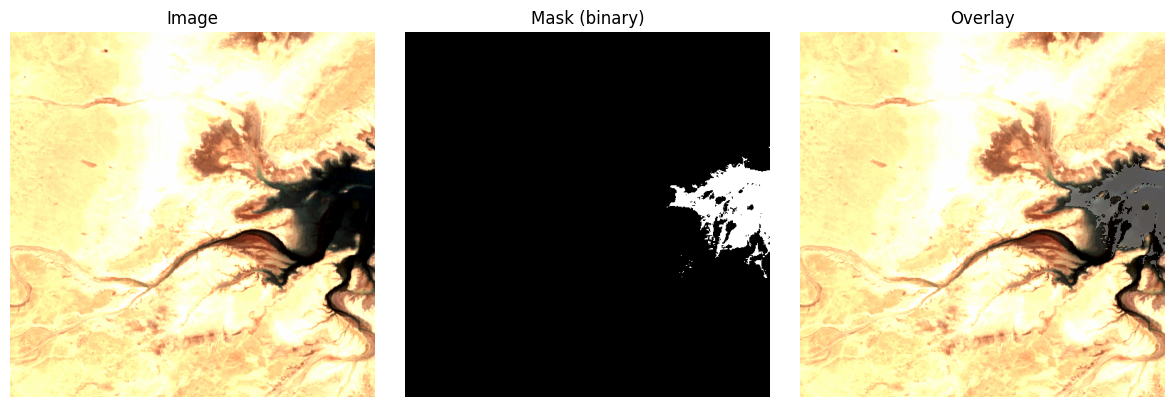

Image shape: (512, 512, 4) dtype: float32
Mask shape: (512, 512) dtype: uint8 mask min/max: 0 1
Water pixel ratio: 0.03725433349609375


In [201]:
# Show example train image

fname = "tharthar_2021_r015_c008.npy"
split = "training"
# =========================
# 2) LOAD ONE TILE
# =========================

img_path  = os.path.join(base_dir3, split, "images", fname)
mask_path = os.path.join(base_dir3, split, "masks",  fname)

img  = np.load(img_path).astype(np.float32)  # (H,W,4)
mask = np.load(mask_path)

# masks might be (H,W,1)
if mask.ndim == 3 and mask.shape[-1] == 1:
    mask = mask[..., 0]

# =========================
# 3) MAKE TRUE-COLOUR RGB (B4,B3,B2) + PER-CHANNEL STRETCH
# =========================
# Assuming band order is [B2,B3,B4,B8] -> RGB = [B4,B3,B2] = indices [2,1,0]
rgb = img[..., [2, 1, 0]]

rgb_disp = np.zeros_like(rgb, dtype=np.float32)
for c in range(3):
    p2, p98 = np.percentile(rgb[..., c], (2, 98))
    rgb_disp[..., c] = np.clip((rgb[..., c] - p2) / (p98 - p2 + 1e-6), 0, 1)

# =========================
# 4) MASK -> BINARY
# =========================
m = mask.astype(np.float32)
if m.max() > 1.5:  # e.g., 0/255
    m = m / 255.0
m_bin = (m > 0.5).astype(np.uint8)

# =========================
# 5) PLOT
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb_disp)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(m_bin, cmap="gray")
plt.title("Mask (binary)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rgb_disp)
plt.imshow(np.ma.masked_where(m_bin == 0, m_bin), cmap="Reds", alpha=0.35)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", img.shape, "dtype:", img.dtype)
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "mask min/max:", mask.min(), mask.max())
print("Water pixel ratio:", float(m_bin.mean()))

In [202]:
# =========================
# PRE-PROCESS DATA: NO TRANSPOSE FOR 4-BAND DATA
# =========================

# Images: just ensure float32, no transpose
for i in range(len(training_images3)):
    training_images3[i] = training_images3[i].astype('float32')

for i in range(len(validation_images3)):
    validation_images3[i] = validation_images3[i].astype('float32')

for i in range(len(test_images3)):
    test_images3[i] = test_images3[i].astype('float32')

# Masks: just ensure correct shape, no transpose
for i in range(len(training_masks3)):
    if training_masks3[i].ndim == 2:
        training_masks3[i] = training_masks3[i][..., np.newaxis]  # (512, 512, 1)

for i in range(len(validation_masks3)):
    if validation_masks3[i].ndim == 2:
        validation_masks3[i] = validation_masks3[i][..., np.newaxis]

for i in range(len(test_masks3)):
    if test_masks3[i].ndim == 2:
        test_masks3[i] = test_masks3[i][..., np.newaxis]

# Convert to numpy arrays
training_images3 = np.array(training_images3, dtype=np.float32)
training_masks3 = np.array(training_masks3, dtype=np.uint8)

validation_images3 = np.array(validation_images3, dtype=np.float32)
validation_masks3 = np.array(validation_masks3, dtype=np.uint8)

test_images3 = np.array(test_images3, dtype=np.float32)
test_masks3 = np.array(test_masks3, dtype=np.uint8)

# =========================
# VERIFY FINAL SHAPES
# =========================

print("\n" + "="*60)
print("AFTER PREPROCESSING:")
print("="*60)
print(f"Training images shape: {training_images3.shape}")  # Should be (N, 512, 512, 4)
print(f"Training masks shape: {training_masks3.shape}")    # Should be (N, 512, 512, 1)
print(f"Validation images shape: {validation_images3.shape}")
print(f"Validation masks shape: {validation_masks3.shape}")
print(f"Test images shape: {test_images3.shape}")
print(f"Test masks shape: {test_masks3.shape}")
print("="*60)



AFTER PREPROCESSING:
Training images shape: (250, 512, 512, 4)
Training masks shape: (250, 512, 512, 1)
Validation images shape: (56, 512, 512, 4)
Validation masks shape: (56, 512, 512, 1)
Test images shape: (20, 512, 512, 4)
Test masks shape: (20, 512, 512, 1)


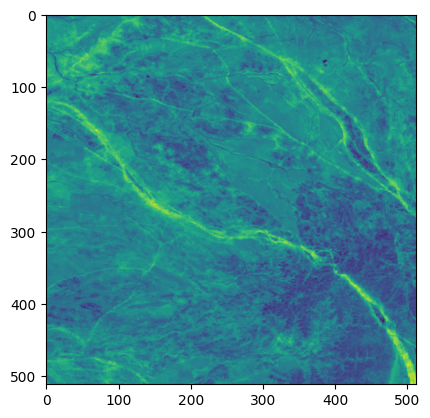

In [203]:
# Plot example training image first band
plt.imshow(training_images3[0].reshape(512,512,4)[:,:,0])

In [204]:
# Create TensorFlow datasets for training and validation sets (Lakes)
train_df_4band_lakes = tf.data.Dataset.from_tensor_slices((training_images3[0:250], training_masks3[0:250]))
train_df_4band_lakes = train_df_4band_lakes.batch(1)

validation_df_4band_lakes = tf.data.Dataset.from_tensor_slices((validation_images3, validation_masks3))
validation_df_4band_lakes = validation_df_4band_lakes.batch(1)

# Models

## U-Net

In [205]:
'''
  Convolutional block with set parameters and activation layer after
'''

def convBlock(input, filters, kernel, kernel_init='he_normal', act='relu', transpose=False):
  if transpose == False:
    #conv = ZeroPadding2D((1,1))(input)
    conv = Conv2D(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)
  else:
    #conv = ZeroPadding2D((1,1))(input)
    conv = Conv2DTranspose(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)

  conv = Activation(act)(conv)
  return conv

'''
  U-Net model
'''

def UNet(trained_weights = None, input_size = (512,512,4), drop_rate = 0.25, lr=0.0001):

    ## Can add pretrained weights by specifying 'trained_weights'

    # Input layer
    inputs = Input(input_size)

    ## Contraction phase
    conv1 = convBlock(inputs, 64, 3)
    conv1 = convBlock(conv1, 64, 3)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = convBlock(pool1, 128, 3)
    conv2 = convBlock(conv2, 128, 3)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    #drop2 = Dropout(drop_rate)(pool2)

    conv3 = convBlock(pool2, 256, 3)
    conv3 = convBlock(conv3, 256, 3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    #drop3 = Dropout(drop_rate)(pool3)

    conv4 = convBlock(pool3, 512, 3)
    conv4 = convBlock(conv4, 512, 3)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)
    #drop4 = Dropout(drop_rate)(pool4)

    conv5 = convBlock(pool4, 1024, 3)
    conv5 = convBlock(conv5, 1024, 3)

    ## Expansion phase
    up6 = (Conv2DTranspose(512, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv5))
    merge6 = concatenate([conv4,up6])
    conv6 = convBlock(merge6, 512, 3)
    conv6 = convBlock(conv6, 512, 3)
    #conv6 = Dropout(drop_rate)(conv6)

    up7 = (Conv2DTranspose(256, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv6))
    merge7 = concatenate([conv3,up7])
    conv7 = convBlock(merge7, 256, 3)
    conv7 = convBlock(conv7, 256, 3)
    #conv7 = Dropout(drop_rate)(conv7)

    up8 = (Conv2DTranspose(128, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv7))
    merge8 = concatenate([conv2,up8])
    conv8 = convBlock(merge8, 128, 3)
    conv8 = convBlock(conv8, 128, 3)
    #conv8 = Dropout(drop_rate)(conv8)

    up9 = (Conv2DTranspose(64, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv8))
    merge9 = concatenate([conv1,up9])
    conv9 = convBlock(merge9, 64, 3)
    conv9 = convBlock(conv9, 64, 3)

    # Output layer
    conv10 = convBlock(conv9, 1, 1, act='sigmoid')

    model = Model(inputs, conv10)

    model.compile(optimizer = Adam(learning_rate = lr), loss = 'binary_crossentropy', metrics = ['accuracy', 'mse'])

    if trained_weights != None:
    	model.load_weights(trained_weights)

    return model

In [206]:
# Print model layers and number of parameters
UNet().summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_469 (Conv2D) │ (None, 512, 512,  │      2,368 │ input_layer_19[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_433      │ (None, 512, 512,  │          0 │ conv2d_469[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_470 (Conv2D) │ (None, 512, 512,  │     36,928 │ activation_433[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_434      │ (None, 512, 512,  │          0 │ conv2d_470[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_112   │ (None, 256, 256,  │          0 │ activation_434[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_471 (Conv2D) │ (None, 256, 256,  │     73,856 │ max_pooling2d_11… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_435      │ (None, 256, 256,  │          0 │ conv2d_471[0][0]  │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_472 (Conv2D) │ (None, 256, 256,  │    147,584 │ activation_435[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_436      │ (None, 256, 256,  │          0 │ conv2d_472[0][0]  │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_113   │ (None, 128, 128,  │          0 │ activation_436[0… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_473 (Conv2D) │ (None, 128, 128,  │    295,168 │ max_pooling2d_11… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_437      │ (None, 128, 128,  │          0 │ conv2d_473[0][0]  │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_474 (Conv2D) │ (None, 128, 128,  │    590,080 │ activation_437[0… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_438      │ (None, 128, 128,  │          0 │ conv2d_474[0][0]  │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_114   │ (None, 64, 64,    │          0 │ activation_438[0… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_475 (Conv2D) │ (None, 64, 64,    │  1,180,160 │ max_pooling2d_11

 Total params: 31,032,321 (118.38 MB)

 Trainable params: 31,032,321 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

## Attention U-Net

In [207]:
'''
  Convolutional block with two conv layers and two activation layers
'''

def convBlock2(input, filters, kernel, kernel_init='he_normal', act='relu', transpose=False):
  if transpose == False:
    conv = Conv2D(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)
    conv = Activation(act)(conv)
    conv = Conv2D(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(conv)
    conv = Activation(act)(conv)
  else:
    conv = Conv2DTranspose(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)
    conv = Activation(act)(conv)
    conv = Conv2DTranspose(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(conv)
    conv = Activation(act)(conv)

  return conv

'''
  Attention block/mechanism
'''
def attention_block(x, gating, inter_shape, drop_rate=0.25):

    # Find shape of inputs
    shape_x = K.int_shape(x)
    shape_g = K.int_shape(gating)

    ## Process x vector and gating signal
    # x vector input and processing
    theta_x = Conv2D(inter_shape, kernel_size = 1, strides = 1, padding='same', kernel_initializer='he_normal', activation=None)(x)
    theta_x = MaxPooling2D((2,2))(theta_x)
    shape_theta_x = K.int_shape(theta_x)

    # gating signal ""
    phi_g = Conv2D(inter_shape, kernel_size = 1, strides = 1, padding='same', kernel_initializer='he_normal', activation=None)(gating)
    shape_phi_g = K.int_shape(phi_g)

    # Add components
    concat_xg = add([phi_g, theta_x])
    act_xg = Activation('relu')(concat_xg)

    # Apply convolution
    psi = Conv2D(1, kernel_size = 1, strides = 1, padding='same', kernel_initializer='he_normal', activation=None)(act_xg)

    # Apply sigmoid activation
    sigmoid_xg = Activation('sigmoid')(psi)
    shape_sigmoid = K.int_shape(sigmoid_xg)

    # UpSample and resample to correct size
    upsample_psi = UpSampling2D(interpolation='bilinear', size=(shape_x[1] // shape_sigmoid[1], shape_x[2] // shape_sigmoid[2]))(sigmoid_xg)
    y = multiply([upsample_psi, x])

    return y


'''
  Attention U-Net model
'''

def UNetAM(trained_weights = None, input_size = (512,512,3), drop_rate = 0.25, lr=0.0001, filter_base=16):

    ## Can add pretrained weights by specifying 'trained_weights'

    # Input layer
    inputs = Input(input_size, batch_size=1)

    ## Contraction phase
    conv = convBlock2(inputs, filter_base, 3)
    #conv0 = Dropout(drop_rate)(conv0)

    conv0 = MaxPooling2D(pool_size=(2, 2))(conv)
    conv0 = convBlock2(conv0, 2 * filter_base, 3)

    pool0 = MaxPooling2D(pool_size=(2, 2))(conv0)
    conv1 = convBlock2(pool0, 4 * filter_base, 3)
    #conv1 = Dropout(drop_rate)(conv1)

    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv2 = convBlock2(pool1, 8 * filter_base, 3)
    #conv2 = Dropout(drop_rate)(conv2)

    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = convBlock2(pool2, 16 * filter_base, 3)
    #conv3 = Dropout(drop_rate)(conv3)

    ## Expansion phase
    up4 = (Conv2DTranspose(8 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv3))
    merge4 = attention_block(conv2, conv3, 8 * filter_base, drop_rate) # Attention gate
    conv4 = concatenate([up4, merge4])
    conv4 = convBlock2(conv4, 8 * filter_base, 3)

    up5 = (Conv2DTranspose(4 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv4))
    merge5 = attention_block(conv1, conv4, 4 * filter_base, drop_rate) # Attention gate
    conv5 = concatenate([up5, merge5])
    conv5 = convBlock2(conv5, 4 * filter_base, 3)

    up6 = (Conv2DTranspose(2 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv5))
    merge6 = attention_block(conv0, conv5, 2 * filter_base, drop_rate) # Attention gate
    conv6 = concatenate([up6, merge6])
    conv6 = convBlock2(conv6, 2 * filter_base, 3)

    up7 = (Conv2DTranspose(1 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv6))
    merge7 = attention_block(conv, conv6, 1 * filter_base, drop_rate) # Attention gate
    conv7 = concatenate([up7, merge7])
    conv7 = concatenate([up7, conv])
    conv7 = convBlock2(conv7, 1 * filter_base, 3)

    ## Output layer
    out = convBlock(conv7, 1, 1, act='sigmoid')

    model = Model(inputs, out)

    model.compile(optimizer = Adam(learning_rate = lr), loss = binary_crossentropy, metrics = ['accuracy', 'mse'])

    if trained_weights != None:
    	model.load_weights(trained_weights)

    return model

In [208]:
# Print model layers and number of parameters
UNetAM().summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (1, 512, 512, 3)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_488 (Conv2D) │ (1, 512, 512, 16) │        448 │ input_layer_20[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_452      │ (1, 512, 512, 16) │          0 │ conv2d_488[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_489 (Conv2D) │ (1, 512, 512, 16) │      2,320 │ activation_452[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_453      │ (1, 512, 512, 16) │          0 │ conv2d_489[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_116   │ (1, 256, 256, 16) │          0 │ activation_453[0… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_490 (Conv2D) │ (1, 256, 256, 32) │      4,640 │ max_pooling2d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_454      │ (1, 256, 256, 32) │          0 │ conv2d_490[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_491 (Conv2D) │ (1, 256, 256, 32) │      9,248 │ activation_454[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_455      │ (1, 256, 256, 32) │          0 │ conv2d_491[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_117   │ (1, 128, 128, 32) │          0 │ activation_455[0… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_492 (Conv2D) │ (1, 128, 128, 64) │     18,496 │ max_pooling2d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_456      │ (1, 128, 128, 64) │          0 │ conv2d_492[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_493 (Conv2D) │ (1, 128, 128, 64) │     36,928 │ activation_456[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_457      │ (1, 128, 128, 64) │          0 │ conv2d_493[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_118   │ (1, 64, 64, 64)   │          0 │ activation_457[0… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_494 (Conv2D) │ (1, 64, 64, 128)  │     73,856 │ max_pooling2d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_458      │ (1, 64, 64, 128)  │          0 │ conv2d_494[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_495 (Conv2D) │ (1, 64, 64, 128)  │    147,584 │ activation_458[0… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,006,292 (7.65 MB)

 Trainable params: 2,006,292 (7.65 MB)

 Non-trainable params: 0 (0.00 B)

# Train on RGB feature data

## U-Net

In [209]:
# Train U-Net with generator
model_unet = UNet(input_size=(512,512,3), lr=0.0001)
save_model = ModelCheckpoint('unet-3d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
train = trainGenerator(1,  X_train, Y_train, data_gen_args, save_to_dir=None)

model_unet.fit(train, steps_per_epoch=100, epochs=2, validation_data=validation_df, callbacks=[save_model])

Epoch 1/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7920 - loss: 0.4930 - mse: 0.1681
Epoch 1: val_accuracy improved from -inf to 0.94140, saving model to unet-3d.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 124ms/step - accuracy: 0.7927 - loss: 0.4918 - mse: 0.1677 - val_accuracy: 0.9414 - val_loss: 0.5631 - val_mse: 0.0587
Epoch 2/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9162 - loss: 0.2654 - mse: 0.0694
Epoch 2: val_accuracy improved from 0.94140 to 0.94140, saving model to unet-3d.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.9162 - loss: 0.2649 - mse: 0.0693 - val_accuracy: 0.9414 - val_loss: 0.1437 - val_mse: 0.0421


In [210]:
# Save model training history
np.save('unet-3d-history.npy',model_unet.history)


In [211]:
# Copy models to drive
!cp unet-3d.keras drive/MyDrive/Diss/
!cp unet-3d-history.npy drive/MyDrive/Diss/

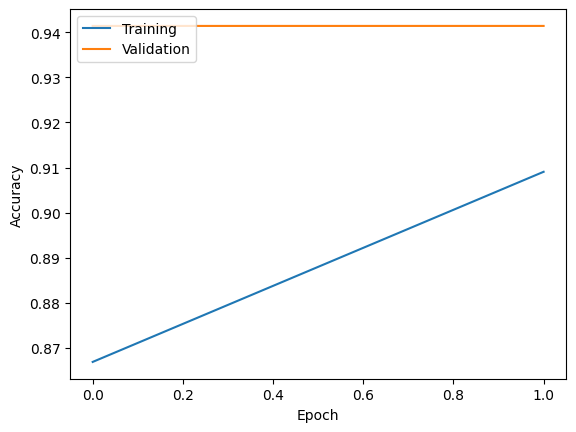

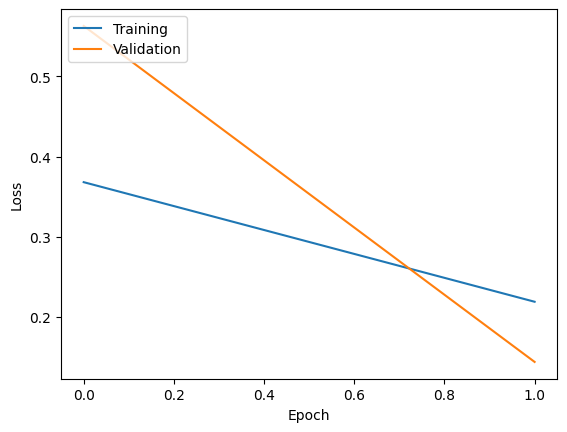

In [212]:
# Plot accuracy and loss

## Accuracy
plt.plot(model_unet.history.history['accuracy'])
plt.plot(model_unet.history.history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(model_unet.history.history['loss'])
plt.plot(model_unet.history.history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

## Attention U-Net

In [213]:
# Train Attention U-Net with generator
model_attention_unet = UNetAM(lr=0.0005, filter_base=16)
save_model_am = ModelCheckpoint('unet-attention-3d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
train = trainGenerator(1,  X_train, Y_train, data_gen_args, save_to_dir=None)
model_attention_unet.fit(train, steps_per_epoch=100, epochs=2, validation_data = validation_df, callbacks=[save_model_am])

Epoch 1/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7216 - loss: 0.5567 - mse: 0.1910
Epoch 1: val_accuracy improved from -inf to 0.94136, saving model to unet-attention-3d.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 107ms/step - accuracy: 0.7228 - loss: 0.5551 - mse: 0.1904 - val_accuracy: 0.9414 - val_loss: 0.4380 - val_mse: 0.0533
Epoch 2/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9162 - loss: 0.2576 - mse: 0.0702
Epoch 2: val_accuracy improved from 0.94136 to 0.94140, saving model to unet-attention-3d.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.9162 - loss: 0.2572 - mse: 0.0701 - val_accuracy: 0.9414 - val_loss: 0.1551 - val_mse: 0.0426


In [214]:
# Save model history
np.save('unet-attention-3d-history.npy',model_attention_unet.history)

In [215]:
# Copy models to drive
!cp unet-attention-3d.keras drive/MyDrive/Diss/
!cp unet-attention-3d-history.npy drive/MyDrive/Diss/

# Train on 4-band data

## Train on 4-band Marshes data

### U-Net

In [216]:
# Train U-Net with generator
model_unet_4band = UNet()
save_model_4band = ModelCheckpoint('unet-4d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_unet_4band.fit(train_df_4band_marshes, epochs=2, validation_data = validation_df_4band_marshes, callbacks=[save_model_4band])

Epoch 1/2
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8760 - loss: 0.2941 - mse: 0.0991
Epoch 1: val_accuracy improved from -inf to 0.98733, saving model to unet-4d.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.8764 - loss: 0.2934 - mse: 0.0989 - val_accuracy: 0.9873 - val_loss: 0.0386 - val_mse: 0.0109
Epoch 2/2
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9757 - loss: 0.0725 - mse: 0.0204
Epoch 2: val_accuracy improved from 0.98733 to 0.98783, saving model to unet-4d.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.9757 - loss: 0.0724 - mse: 0.0203 - val_accuracy: 0.9878 - val_loss: 0.0410 - val_mse: 0.0095


In [217]:
# Save model history
np.save('unet-4d-history.npy',model_unet_4band.history.history)

In [218]:
# Copy models to drive
!cp unet-4d.keras drive/MyDrive/Diss/
!cp unet-4d-history.npy drive/MyDrive/Diss/

### Attention U-Net

In [219]:
# Train U-Net with generator
model_attention_unet_4band = UNetAM(input_size=(512,512,4), filter_base=16, lr=0.0005)
save_model_4band_attention = ModelCheckpoint('unet-attention-4d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_attention_unet_4band.fit(train_df_4band_marshes, epochs = 2, validation_data = validation_df_4band_marshes, callbacks=[save_model_4band_attention])

Epoch 1/2
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8940 - loss: 0.2800 - mse: 0.0922
Epoch 1: val_accuracy improved from -inf to 0.98901, saving model to unet-attention-4d.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.8943 - loss: 0.2793 - mse: 0.0919 - val_accuracy: 0.9890 - val_loss: 0.0367 - val_mse: 0.0086
Epoch 2/2
140/143 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9793 - loss: 0.0546 - mse: 0.0154
Epoch 2: val_accuracy improved from 0.98901 to 0.98998, saving model to unet-attention-4d.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9794 - loss: 0.0543 - mse: 0.0154 - val_accuracy: 0.9900 - val_loss: 0.0278 - val_mse: 0.0076


In [220]:
# Save model history
np.save('unet-attention-4d-history.npy',model_attention_unet_4band.history.history)

In [221]:
# Copy models to drive
!cp unet-attention-4d.keras drive/MyDrive/Diss/
!cp unet-attention-4d-history.npy drive/MyDrive/Diss/

## Train on 4-band Lakes data

### U-Net

In [222]:
# Train U-Net with generator
model_unet_4band_lakes = UNet()
save_model_4band_lakes = ModelCheckpoint('unet-4d-lakes.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_unet_4band_lakes.fit(train_df_4band_lakes, epochs = 2, validation_data = validation_df_4band_lakes, callbacks=[save_model_4band_lakes])

Epoch 1/2
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8480 - loss: 0.3067 - mse: 0.1053
Epoch 1: val_accuracy improved from -inf to 0.99362, saving model to unet-4d-lakes.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.8488 - loss: 0.3054 - mse: 0.1048 - val_accuracy: 0.9936 - val_loss: 0.0185 - val_mse: 0.0051
Epoch 2/2
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9964 - loss: 0.0128 - mse: 0.0028
Epoch 2: val_accuracy improved from 0.99362 to 0.99456, saving model to unet-4d-lakes.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.9964 - loss: 0.0128 - mse: 0.0028 - val_accuracy: 0.9946 - val_loss: 0.0168 - val_mse: 0.0044


In [223]:
# Save model history
np.save('unet-4d-lakes-history.npy',model_unet_4band_lakes.history.history)

In [224]:
# Copy models to drive
!cp unet-4d-lakes.keras drive/MyDrive/Diss/
!cp unet-4d-lakes-history.npy drive/MyDrive/Diss/

### Attention U-Net

In [225]:
# Train Attention U-Net with generator
model_attention_unet_4band_lakes = UNetAM(input_size=(512,512,4), filter_base=16, lr=0.0005)
save_model_4band_attention_lakes = ModelCheckpoint('unet-attention-4d-lakes.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_attention_unet_4band_lakes.fit(train_df_4band_lakes, epochs = 2, validation_data = validation_df_4band_lakes, callbacks=[save_model_4band_attention_lakes])

Epoch 1/2
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7888 - loss: 0.5566 - mse: 0.1608
Epoch 1: val_accuracy improved from -inf to 0.99074, saving model to unet-attention-4d-lakes.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.7894 - loss: 0.5547 - mse: 0.1603 - val_accuracy: 0.9907 - val_loss: 0.0465 - val_mse: 0.0109
Epoch 2/2
246/250 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9939 - loss: 0.0234 - mse: 0.0051
Epoch 2: val_accuracy improved from 0.99074 to 0.99276, saving model to unet-attention-4d-lakes.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9939 - loss: 0.0233 - mse: 0.0051 - val_accuracy: 0.9928 - val_loss: 0.0215 - val_mse: 0.0058


In [226]:
# Save model history
np.save('unet-attention-4d-lakes-history.npy',model_attention_unet_4band_lakes.history.history)

In [227]:
# Copy models to drive
!cp unet-attention-4d-lakes.keras drive/MyDrive/Diss/
!cp unet-attention-4d-lakes-history.npy drive/MyDrive/Diss/

# Import Models and Compute Metrics

## RGB

In [228]:
# Load 3-dim models and history stats
attention_unet = load_model('unet-attention-3d.keras')
unet = load_model('unet-3d.keras')

unet_history = np.load('unet-3d-history.npy', allow_pickle='TRUE').item()
attention_unet_history = np.load('unet-attention-3d-history.npy', allow_pickle='TRUE').item()

Epoch 1/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8801 - loss: 0.2414 - mse: 0.0781
Epoch 1: val_accuracy improved from 0.94140 to 0.95104, saving model to unet-3d.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - accuracy: 0.8799 - loss: 0.2415 - mse: 0.0781 - val_accuracy: 0.9510 - val_loss: 0.0991 - val_mse: 0.0315
Epoch 2/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9104 - loss: 0.2184 - mse: 0.0711
Epoch 2: val_accuracy did not improve from 0.95104
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.9104 - loss: 0.2183 - mse: 0.0710 - val_accuracy: 0.9430 - val_loss: 0.1576 - val_mse: 0.0403


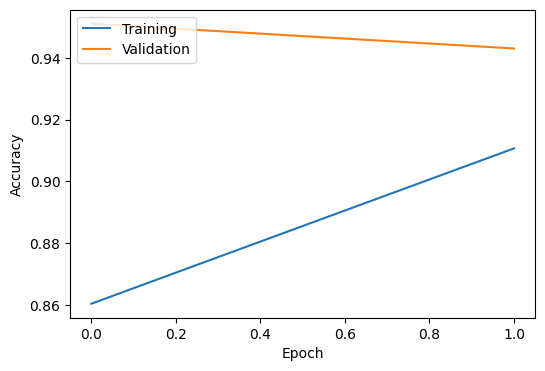

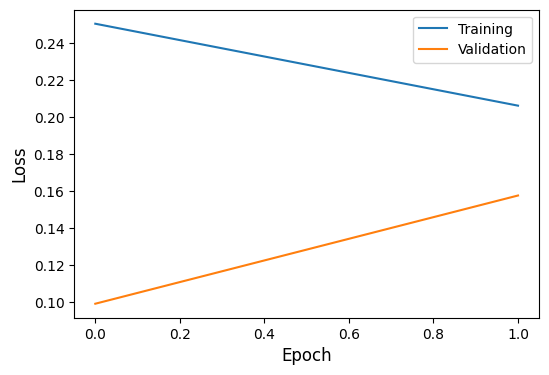

In [229]:
# Plot accuracy and loss for U-Net
unet_history_obj = model_unet.fit(train, steps_per_epoch=100, epochs=2, validation_data=validation_df, callbacks=[save_model])
unet_history = unet_history_obj.history
## Accuracy
plt.figure(figsize=(6, 4))
plt.plot(unet_history['accuracy'])
plt.plot(unet_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.figure(figsize=(6, 4))
plt.plot(unet_history['loss'])
plt.plot(unet_history['val_loss'])
plt.ylabel('Loss', size=12)
plt.xlabel('Epoch', size=12)
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

In [230]:
# Scores of each model
unet_score = (score_eval(unet, validation_images, validation_masks))
am_unet_score = (score_eval(attention_unet, validation_images, validation_masks))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━

In [231]:
# Process one image at a time
def evaluate_one_by_one(model, X, Y, eval_func):
    """Evaluate each sample individually and average results."""
    results = []
    num_samples = len(X)

    for i in range(num_samples):
        x_single = X[i:i+1]  # Shape: (1, 512, 512, 3)
        y_single = Y[i:i+1]  # Shape: (1, 512, 512, 1)

        result = eval_func(model, x_single, y_single)
        results.append(result)

        if (i + 1) % 10 == 0:
            print(f"Processed {i+1}/{num_samples} samples...")

    return np.mean(results)


# Precision and recall of each model (one at a time)
print("Evaluating U-Net precision...")
unet_precision = evaluate_one_by_one(unet, X_val, Y_val, precision_eval)

print("\nEvaluating U-Net recall...")
unet_recall = evaluate_one_by_one(unet, X_val, Y_val, recall_eval)

print("\nEvaluating Attention U-Net precision...")
am_unet_precision = evaluate_one_by_one(attention_unet, X_val, Y_val, precision_eval)

print("\nEvaluating Attention U-Net recall...")
am_unet_recall = evaluate_one_by_one(attention_unet, X_val, Y_val, recall_eval)

print(f"\nU-Net - Precision: {unet_precision:.4f}, Recall: {unet_recall:.4f}")
print(f"Attention U-Net - Precision: {am_unet_precision:.4f}, Recall: {am_unet_recall:.4f}")


Evaluating U-Net precision...
Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...
Processed 60/99 samples...
Processed 70/99 samples...
Processed 80/99 samples...
Processed 90/99 samples...

Evaluating U-Net recall...
Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...
Processed 60/99 samples...
Processed 70/99 samples...
Processed 80/99 samples...
Processed 90/99 samples...

Evaluating Attention U-Net precision...
Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...
Processed 60/99 samples...
Processed 70/99 samples...
Processed 80/99 samples...
Processed 90/99 samples...

Evaluating Attention U-Net recall...
Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...

In [232]:
# F1-scores of each model
unet_f1_score = f1_score_eval_basic(unet_precision, unet_recall)
am_unet_f1_score = f1_score_eval_basic(am_unet_precision, am_unet_recall)

print(f"U-Net F1-Score: {unet_f1_score:.4f}")
print(f"Attention U-Net F1-Score: {am_unet_f1_score:.4f}")

U-Net F1-Score: 0.9222
Attention U-Net F1-Score: 0.9228


In [233]:
# Print score eval results for each model
print('U-Net accuracy: ', np.mean(unet_score), np.std(unet_score))
print('Attention U-Net accuracy: ', np.mean(am_unet_score), np.std(am_unet_score))

U-Net accuracy:  0.9413998536389283 0.13248852315675683
Attention U-Net accuracy:  0.94139650132921 0.1324883603212854


In [234]:
# Print precision eval results for each model

print(f"\nU-Net - Precision: {unet_precision:.4f}, Recall: {unet_recall:.4f}")
print(f"Attention U-Net - Precision: {am_unet_precision:.4f}, Recall: {am_unet_recall:.4f}")


U-Net - Precision: 0.9038, Recall: 0.9414
Attention U-Net - Precision: 0.9050, Recall: 0.9414


In [235]:
# Print recall eval results for each model
print('U-Net recall: ', np.mean(unet_recall), np.std(unet_recall))
print('Attention U-Net recall: ', np.mean(am_unet_recall), np.std(am_unet_recall))

U-Net recall:  0.9413998536389283 0.0
Attention U-Net recall:  0.94139650132921 0.0


In [236]:
# Print f1-score eval results for each model
print('U-Net F1-score: ', np.mean(unet_f1_score))
print('Attention U-Net F1-score: ', np.mean(am_unet_f1_score))

U-Net F1-score:  0.9222107838763012
Attention U-Net F1-score:  0.9228369831864043


## 4-band

### Marshes Data

In [237]:
# Load 4-dim models and history stats
attention_unet_4d = load_model('unet-attention-4d.keras')
unet_4d = load_model('unet-4d.keras')

unet_4d_history = np.load('unet-4d-history.npy', allow_pickle='TRUE').item()
attention_unet_4d_history = np.load('unet-attention-4d-history.npy', allow_pickle='TRUE').item()

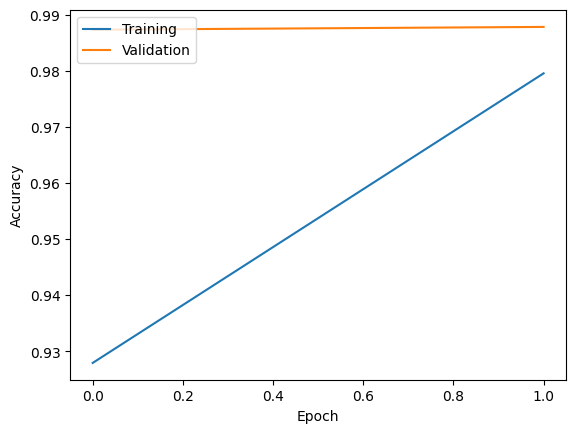

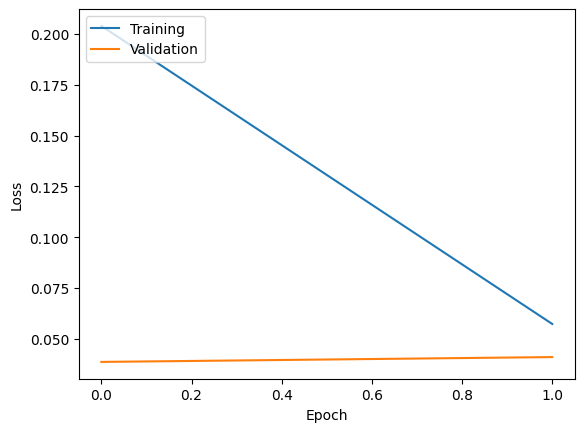

In [238]:
# Plot accuracy and loss for U-Net

## Accuracy
plt.plot(unet_4d_history['accuracy'])
plt.plot(unet_4d_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(unet_4d_history['loss'])
plt.plot(unet_4d_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

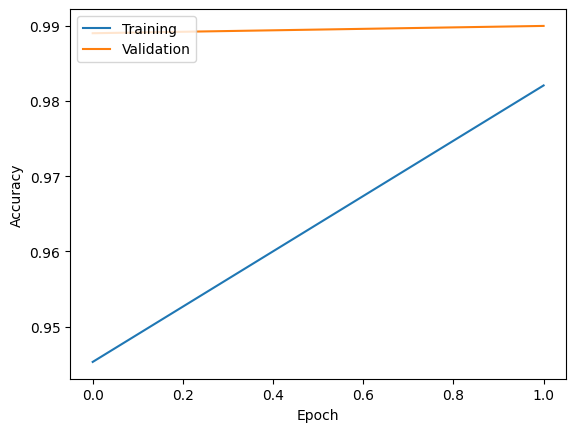

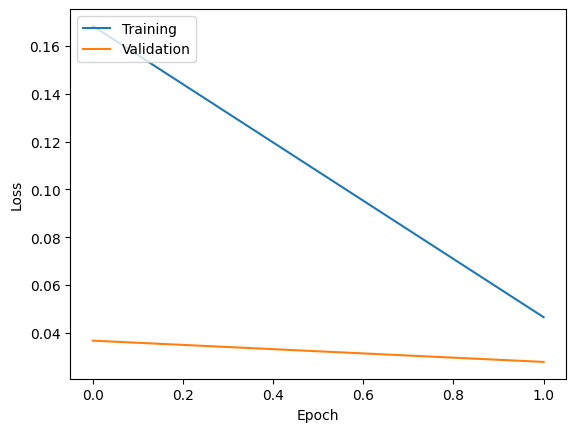

In [239]:
# Plot accuracy and loss for Attention U-Net

## Accuracy
plt.plot(attention_unet_4d_history['accuracy'])
plt.plot(attention_unet_4d_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(attention_unet_4d_history['loss'])
plt.plot(attention_unet_4d_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

In [240]:
# Scores of each model
print("Evaluating U-Net scores...")
unet_4d_score = evaluate_one_by_one(unet_4d, validation_images2, validation_masks2, score_eval2)

print("\nEvaluating Attention U-Net scores...")
am_unet_4d_score = evaluate_one_by_one(attention_unet_4d, validation_images2, validation_masks2, score_eval2)

print(f"\nU-Net mean score: {unet_4d_score:.4f}")
print(f"Attention U-Net mean score: {am_unet_4d_score:.4f}")

Evaluating U-Net scores...
Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...
Processed 60/99 samples...
Processed 70/99 samples...
Processed 80/99 samples...
Processed 90/99 samples...

Evaluating Attention U-Net scores...
Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...
Processed 60/99 samples...
Processed 70/99 samples...
Processed 80/99 samples...
Processed 90/99 samples...

U-Net mean score: 0.9878
Attention U-Net mean score: 0.9900


In [241]:

def evaluate_one_by_one_segmentation(model, X, Y, thresh=0.5):
    tp = fp = fn = 0
    num_samples = len(X)

    for i in range(num_samples):
        x = X[i:i+1]   # (1, H, W, C)
        y = Y[i:i+1]   # (1, H, W, 1)

        y_prob = model.predict(x, verbose=0)
        y_pred = (y_prob > thresh).astype(np.uint8)
        y_true = (y > 0.5).astype(np.uint8)

        yp = y_pred.reshape(-1)
        yt = y_true.reshape(-1)

        tp += np.sum((yp == 1) & (yt == 1))
        fp += np.sum((yp == 1) & (yt == 0))
        fn += np.sum((yp == 0) & (yt == 1))

        if (i + 1) % 10 == 0:
            print(f"Processed {i+1}/{num_samples} samples...")

    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)

    return precision, recall, f1

In [242]:
# Precision and recall of each model
unet_4d_precision = evaluate_one_by_one(
    unet_4d, validation_images2, validation_masks2, precision_eval
)

am_unet_4d_precision = evaluate_one_by_one(
    attention_unet_4d, validation_images2, validation_masks2, precision_eval
)

unet_4d_recall = evaluate_one_by_one(
    unet_4d, validation_images2, validation_masks2, recall_eval
)

am_unet_4d_recall = evaluate_one_by_one(
    attention_unet_4d, validation_images2, validation_masks2, recall_eval
)


Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...
Processed 60/99 samples...
Processed 70/99 samples...
Processed 80/99 samples...
Processed 90/99 samples...
Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...
Processed 60/99 samples...
Processed 70/99 samples...
Processed 80/99 samples...
Processed 90/99 samples...
Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...
Processed 60/99 samples...
Processed 70/99 samples...
Processed 80/99 samples...
Processed 90/99 samples...
Processed 10/99 samples...
Processed 20/99 samples...
Processed 30/99 samples...
Processed 40/99 samples...
Processed 50/99 samples...
Processed 60/99 samples...
Processed 70/99 samples...
Processed 80/99 samples...
Processed 90/99 samples...


In [243]:
# F1-scores of each model
unet_4d_f1_score = (f1_score_eval_basic(unet_4d_precision, unet_4d_recall))
am_unet_4d_f1_score = (f1_score_eval_basic(am_unet_4d_precision, am_unet_4d_recall))

In [244]:
# Print score eval results for each model
print('U-Net accuracy: ', np.mean(unet_4d_score), np.std(unet_4d_score))
print('Attention U-Net accuracy: ', np.mean(am_unet_4d_score), np.std(am_unet_4d_score))

U-Net accuracy:  0.987827956074416 0.0
Attention U-Net accuracy:  0.9899782508310645 0.0


In [245]:
# Print precision eval results for each model
print('U-Net precision: ', np.mean(unet_4d_precision), np.std(unet_4d_precision))
print('Attention U-Net precision: ', np.mean(am_unet_4d_precision), np.std(am_unet_4d_precision))

U-Net precision:  0.9879990524722831 0.0
Attention U-Net precision:  0.9900511262959345 0.0


In [246]:
# Print recall eval results for each model
print('U-Net recall: ', np.mean(unet_4d_recall), np.std(unet_4d_recall))
print('Attention U-Net recall: ', np.mean(am_unet_4d_recall), np.std(am_unet_4d_recall))

U-Net recall:  0.987827956074416 0.0
Attention U-Net recall:  0.9899782508310645 0.0


In [247]:
# Print f1-score eval results for each model
print('U-Net F1-score: ', np.mean(unet_4d_f1_score))
print('Attention U-Net F1-score: ', np.mean(am_unet_4d_f1_score))

U-Net F1-score:  0.9879134968653182
Attention U-Net F1-score:  0.9900146872223999


### Marshes on unseen Lakes data

In [248]:

# Score
unet_marshes_on_lakes_score = score_eval2(
    unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)
am_unet_marshes_on_lakes_score = score_eval2(
    attention_unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)

# Precision
unet_marshes_on_lakes_precision = precision_eval(
    unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)
am_unet_marshes_on_lakes_precision = precision_eval(
    attention_unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)

# Recall
unet_marshes_on_lakes_recall = recall_eval(
    unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)
am_unet_marshes_on_lakes_recall = recall_eval(
    attention_unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)

# F1-scores
unet_marshes_on_lakes_f1_score = f1_score_eval_basic(
    unet_marshes_on_lakes_precision,
    unet_marshes_on_lakes_recall
)
am_unet_marshes_on_lakes_f1_score = f1_score_eval_basic(
    am_unet_marshes_on_lakes_precision,
    am_unet_marshes_on_lakes_recall
)

In [249]:
# Score
unet_marshes_on_lakes_score = score_eval2(
    unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)
am_unet_marshes_on_lakes_score = score_eval2(
    attention_unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)

# Precision
unet_marshes_on_lakes_precision = precision_eval(
    unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)
am_unet_marshes_on_lakes_precision = precision_eval(
    attention_unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)

# Recall
unet_marshes_on_lakes_recall = recall_eval(
    unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)
am_unet_marshes_on_lakes_recall = recall_eval(
    attention_unet_4d,
    np.concatenate([validation_images3, test_images3], axis=0),
    np.concatenate([validation_masks3, test_masks3], axis=0)
)

# F1-scores of each model
unet_marshes_on_lakes_f1_score = f1_score_eval_basic(
    unet_marshes_on_lakes_precision,
    unet_marshes_on_lakes_recall
)
am_unet_marshes_on_lakes_f1_score = f1_score_eval_basic(
    am_unet_marshes_on_lakes_precision,
    am_unet_marshes_on_lakes_recall
)

In [250]:
# Print metrics
print('U-Net score: ', np.mean(unet_marshes_on_lakes_score), np.std(unet_marshes_on_lakes_score))
print('Attention U-Net score: ', np.mean(am_unet_marshes_on_lakes_score), np.std(am_unet_marshes_on_lakes_score))

print('U-Net precision: ', np.mean(unet_marshes_on_lakes_precision), np.std(unet_marshes_on_lakes_precision))
print('Attention U-Net precision: ', np.mean(am_unet_marshes_on_lakes_precision), np.std(am_unet_marshes_on_lakes_precision))

print('U-Net recall: ', np.mean(unet_marshes_on_lakes_recall), np.std(unet_marshes_on_lakes_recall))
print('Attention U-Net recall: ', np.mean(am_unet_marshes_on_lakes_recall), np.std(am_unet_marshes_on_lakes_recall))

print('U-Net F1-score: ', unet_marshes_on_lakes_f1_score)
print('Attention U-Net F1-score: ', am_unet_marshes_on_lakes_f1_score)

U-Net score:  0.9946150528757196 0.008454832908546943
Attention U-Net score:  0.9961819899709601 0.006309768685691298
U-Net precision:  0.9947715096312985 0.008055169839344102
Attention U-Net precision:  0.9962917401776714 0.0060564932847551
U-Net recall:  0.9946150528757196 0.008454832908546943
Attention U-Net recall:  0.9961819899709601 0.006309768685691298
U-Net F1-score:  0.9946932751011813
Attention U-Net F1-score:  0.9962368620516642


### Lakes Data

In [251]:
# Load 4-dim models and history stats
attention_unet_4d_lakes = load_model('unet-attention-4d-lakes.keras')
unet_4d_lakes = load_model('unet-4d-lakes.keras')

unet_4d_lakes_history = np.load('unet-4d-lakes-history.npy', allow_pickle='TRUE').item()
attention_unet_4d_lakes_history = np.load('unet-attention-4d-lakes-history.npy', allow_pickle='TRUE').item()

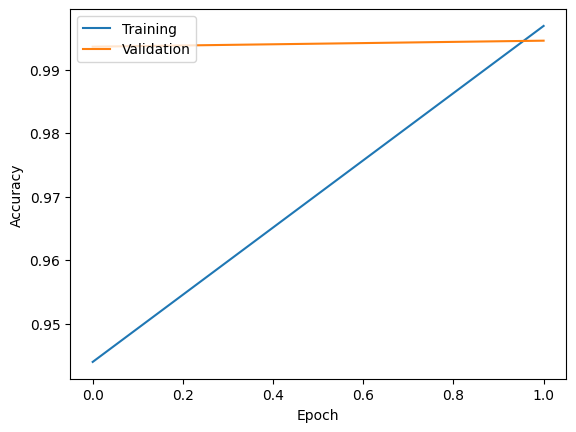

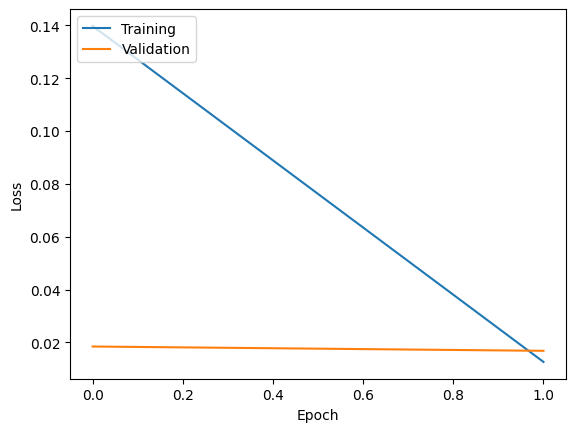

In [252]:
# Plot accuracy and loss for U-Net

## Accuracy
plt.plot(unet_4d_lakes_history['accuracy'])
plt.plot(unet_4d_lakes_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(unet_4d_lakes_history['loss'])
plt.plot(unet_4d_lakes_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

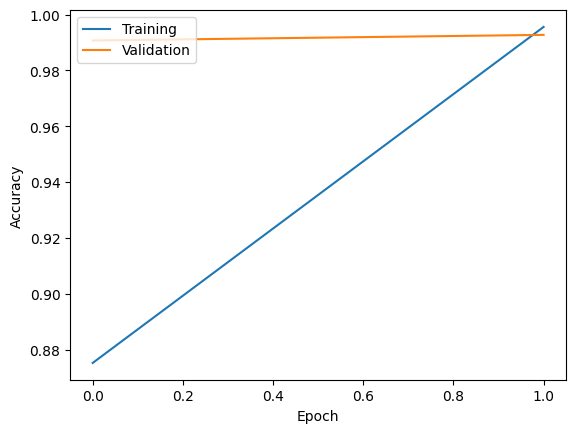

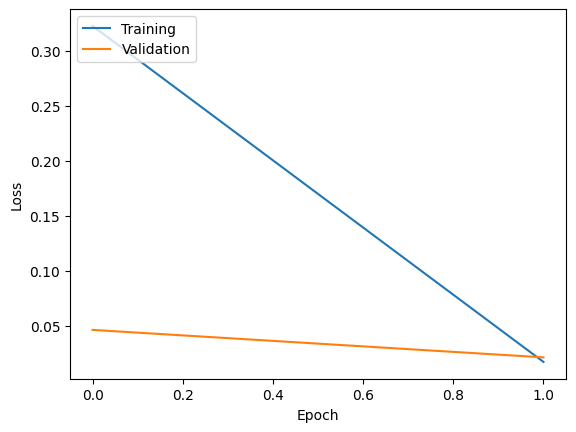

In [253]:
# Plot accuracy and loss for Attention U-Net

## Accuracy
plt.plot(attention_unet_4d_lakes_history['accuracy'])
plt.plot(attention_unet_4d_lakes_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(attention_unet_4d_lakes_history['loss'])
plt.plot(attention_unet_4d_lakes_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

In [254]:
# Scores of each model
unet_4d_lakes_score = (score_eval2(unet_4d_lakes, validation_images3, validation_masks3))
am_unet_4d_lakes_score = (score_eval2(attention_unet_4d_lakes, validation_images3, validation_masks3))

# Precision and recall of each model
unet_4d_lakes_precision = (precision_eval(unet_4d_lakes, validation_images3, validation_masks3))
am_unet_4d_lakes_precision = (precision_eval(attention_unet_4d_lakes, validation_images3, validation_masks3))

unet_4d_lakes_recall = (recall_eval(unet_4d_lakes, validation_images3, validation_masks3))
am_unet_4d_lakes_recall = (recall_eval(attention_unet_4d_lakes, validation_images3, validation_masks3))

# F1-scores of each model
unet_4d_lakes_f1_score = (f1_score_eval_basic(unet_4d_lakes_precision, unet_4d_lakes_recall))
am_unet_4d_lakes_f1_score = (f1_score_eval_basic(am_unet_4d_lakes_precision, am_unet_4d_lakes_recall))

In [255]:
# Print metrics
print('U-Net score: ', np.mean(unet_4d_lakes_score), np.std(unet_4d_lakes_score))
print('Attention U-Net score: ', np.mean(am_unet_4d_lakes_score), np.std(am_unet_4d_lakes_score))

print('U-Net precision: ', np.mean(unet_4d_lakes_precision), np.std(unet_4d_lakes_precision))
print('Attention U-Net precision: ', np.mean(am_unet_4d_lakes_precision), np.std(am_unet_4d_lakes_precision))

print('U-Net recall: ', np.mean(unet_4d_lakes_recall), np.std(unet_4d_lakes_recall))
print('Attention U-Net recall: ', np.mean(am_unet_4d_lakes_recall), np.std(am_unet_4d_lakes_recall))

print('U-Net F1-score: ', unet_4d_lakes_f1_score)
print('Attention U-Net F1-score: ', am_unet_4d_lakes_f1_score)

U-Net score:  0.9945615359715053 0.008215997713792002
Attention U-Net score:  0.9927599089486259 0.010800727810834524
U-Net precision:  0.9947528994825562 0.007844644826110142
Attention U-Net precision:  0.9931202753414082 0.010185264530716987
U-Net recall:  0.9945615359715053 0.008215997713792002
Attention U-Net recall:  0.9927599089486259 0.010800727810834524
U-Net F1-score:  0.9946572085228566
Attention U-Net F1-score:  0.9929400594481962


### Lakes on unseen Marshes data

In [256]:
# Score
unet_lakes_on_marshes_score = score_eval2(
    unet_4d_lakes,
    np.concatenate([validation_images2, test_images2], axis=0),
    np.concatenate([validation_masks2, test_masks2], axis=0)
)
am_unet_lakes_on_marshes_score = score_eval2(
    attention_unet_4d_lakes,
    np.concatenate([validation_images2, test_images2], axis=0),
    np.concatenate([validation_masks2, test_masks2], axis=0)
)

# Precision
unet_lakes_on_marshes_precision = precision_eval(
    unet_4d_lakes,
    np.concatenate([validation_images2, test_images2], axis=0),
    np.concatenate([validation_masks2, test_masks2], axis=0)
)
am_unet_lakes_on_marshes_precision = precision_eval(
    attention_unet_4d_lakes,
    np.concatenate([validation_images2, test_images2], axis=0),
    np.concatenate([validation_masks2, test_masks2], axis=0)
)

# Recall
unet_lakes_on_marshes_recall = recall_eval(
    unet_4d_lakes,
    np.concatenate([validation_images2, test_images2], axis=0),
    np.concatenate([validation_masks2, test_masks2], axis=0)
)
am_unet_lakes_on_marshes_recall = recall_eval(
    attention_unet_4d_lakes,
    np.concatenate([validation_images2, test_images2], axis=0),
    np.concatenate([validation_masks2, test_masks2], axis=0)
)

# F1-scores of each model
unet_lakes_on_marshes_f1_score = f1_score_eval_basic(
    unet_lakes_on_marshes_precision,
    unet_lakes_on_marshes_recall
)
am_unet_lakes_on_marshes_f1_score = f1_score_eval_basic(
    am_unet_lakes_on_marshes_precision,
    am_unet_lakes_on_marshes_recall
)


In [257]:
# Print metrics
print('U-Net score: ', np.mean(unet_lakes_on_marshes_score), np.std(unet_lakes_on_marshes_score))
print('Attention U-Net score: ', np.mean(am_unet_lakes_on_marshes_score), np.std(am_unet_lakes_on_marshes_score))

print('U-Net precision: ', np.mean(unet_lakes_on_marshes_precision), np.std(unet_lakes_on_marshes_precision))
print('Attention U-Net precision: ', np.mean(am_unet_lakes_on_marshes_precision), np.std(am_unet_lakes_on_marshes_precision))

print('U-Net recall: ', np.mean(unet_lakes_on_marshes_recall), np.std(unet_lakes_on_marshes_recall))
print('Attention U-Net recall: ', np.mean(am_unet_lakes_on_marshes_recall), np.std(am_unet_lakes_on_marshes_recall))

print('U-Net F1-score: ', unet_lakes_on_marshes_f1_score)
print('Attention U-Net F1-score: ', am_unet_lakes_on_marshes_f1_score)

U-Net score:  0.9839714755531118 0.0349330995644237
Attention U-Net score:  0.9798468902331441 0.04697822622644758
U-Net precision:  0.9847976839436468 0.030381066443208746
Attention U-Net precision:  0.9819553675892713 0.035760545182217746
U-Net recall:  0.9839714755531118 0.0349330995644237
Attention U-Net recall:  0.9798468902331441 0.04697822622644758
U-Net F1-score:  0.9843844063861795
Attention U-Net F1-score:  0.9808999958518629


### Marshes and Lakes unseen test data

In [258]:
# Marshes trained model on Marshes test data
# Scores of each model
unet_4d_score_test = (score_eval2(unet_4d, test_images2, test_masks2))
am_unet_4d_score_test = (score_eval2(attention_unet_4d, test_images2, test_masks2))

# Precision and recall of each model
unet_4d_precision_test = (precision_eval(unet_4d, test_images2, test_masks2))
am_unet_4d_precision_test = (precision_eval(attention_unet_4d, test_images2, test_masks2))

unet_4d_recall_test = (recall_eval(unet_4d, test_images2, test_masks2))
am_unet_4d_recall_test = (recall_eval(attention_unet_4d, test_images2, test_masks2))

# F1-scores of each model
unet_4d_f1_score_test = (f1_score_eval_basic(unet_4d_precision_test, unet_4d_recall_test))
am_unet_4d_f1_score_test = (f1_score_eval_basic(am_unet_4d_precision_test, am_unet_4d_recall_test))

# Marshes trained model on Lakes test data
# Scores of each model
unet_4d_lakes_score_test = (score_eval2(unet_4d, test_images3, test_masks3))
am_unet_4d_lakes_score_test = (score_eval2(attention_unet_4d, test_images3, test_masks3))

# Precision and recall of each model
unet_4d_lakes_precision_test = (precision_eval(unet_4d, test_images3, test_masks3))
am_unet_4d_lakes_precision_test = (precision_eval(attention_unet_4d, test_images3, test_masks3))

unet_4d_lakes_recall_test = (recall_eval(unet_4d, test_images3, test_masks3))
am_unet_4d_lakes_recall_test = (recall_eval(attention_unet_4d, test_images3, test_masks3))

# F1-scores of each model
unet_4d_lakes_f1_score_test = (f1_score_eval_basic(unet_4d_lakes_precision_test, unet_4d_lakes_recall_test))
am_unet_4d_lakes_f1_score_test = (f1_score_eval_basic(am_unet_4d_lakes_precision_test, am_unet_4d_lakes_recall_test))

# Print metrics for Marshes on Marshes Test set
print('U-Net score (Marshes-trained on Marshes Test Data): ', np.mean(unet_4d_score_test), np.std(unet_4d_score_test))
print('Attention U-Net score (Marshes-trained on Marshes Test Data): ', np.mean(am_unet_4d_score_test), np.std(am_unet_4d_score_test))

# Print metrics for Marshes on Lakes Test set (CROSS-DATASET EVALUATION)
print('\nU-Net score (Marshes-trained on Lakes Test Data): ', np.mean(unet_4d_lakes_score_test), np.std(unet_4d_lakes_score_test))
print('Attention U-Net score (Marshes-trained on Lakes Test Data): ', np.mean(am_unet_4d_lakes_score_test), np.std(am_unet_4d_lakes_score_test))

U-Net score (Marshes-trained on Marshes Test Data):  0.9821287155151367 0.026136546576114993
Attention U-Net score (Marshes-trained on Marshes Test Data):  0.9841938018798828 0.025983603462022803

U-Net score (Marshes-trained on Lakes Test Data):  0.9963859558105469 0.006310403430687419
Attention U-Net score (Marshes-trained on Lakes Test Data):  0.9978471755981445 0.0037259111668289766


# Produce metric datasets for export

## RGB data

In [259]:
scores = [unet_score, am_unet_score]
precision = [unet_precision, am_unet_precision]
recall = [unet_recall, am_unet_recall]
f1_scores = [unet_f1_score, am_unet_f1_score]

metrics = {'classifier': ['U-Net', 'Attention U-Net'],
           'accuracy': [np.mean(n) for n in scores],
           'precision': precision,
           'recall': recall,
           'f1_score': f1_scores,
           'accuracy_std': [np.std(n) for n in scores]
          }

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv('metrics_3d_marshes.csv', index=False)

# Display the results
print(metrics_df)

        classifier  accuracy  precision    recall  f1_score  accuracy_std
0            U-Net  0.941400   0.903788  0.941400  0.922211      0.132489
1  Attention U-Net  0.941397   0.904995  0.941397  0.922837      0.132488


## 4-band Amazon data

In [260]:
scores_4d = [unet_4d_score, am_unet_4d_score]
precision_4d = [unet_4d_precision, am_unet_4d_precision]
recall_4d = [unet_4d_recall, am_unet_4d_recall]
f1_scores_4d = [unet_4d_f1_score, am_unet_4d_f1_score]

metrics_4d = {'classifier': ['U-Net', 'Attention U-Net'],
              'accuracy': [np.mean(n) for n in scores_4d],
              'precision': [np.mean(n) for n in precision_4d],
              'recall': [np.mean(n) for n in recall_4d],
              'f1_score': [np.mean(n) for n in f1_scores_4d],
              'accuracy_std': [np.std(n) for n in scores_4d],
              'precision_std': [np.std(n) for n in precision_4d],
              'recall_std': [np.std(n) for n in recall_4d]
              }
metrics_4d = pd.DataFrame(metrics_4d)
metrics_4d.to_csv('metrics_4d_marshes.csv', index=False)

# Display results
print(metrics_4d)

        classifier  accuracy  precision    recall  f1_score  accuracy_std  \
0            U-Net  0.987828   0.987999  0.987828  0.987913           0.0   
1  Attention U-Net  0.989978   0.990051  0.989978  0.990015           0.0   

   precision_std  recall_std  
0            0.0         0.0  
1            0.0         0.0  


## 4-band Atlantic Forest data

In [261]:
scores_4d_lakes = [unet_4d_lakes_score, am_unet_4d_lakes_score]
precision_4d_lakes = [unet_4d_lakes_precision, am_unet_4d_lakes_precision]
recall_4d_lakes = [unet_4d_lakes_recall, am_unet_4d_lakes_recall]
f1_scores_4d_lakes = [unet_4d_lakes_f1_score, am_unet_4d_lakes_f1_score]

metrics_4d_lakes = {'classifier': ['U-Net', 'Attention U-Net'],
                    'accuracy': [np.mean(n) for n in scores_4d_lakes],
                    'precision': [np.mean(n) for n in precision_4d_lakes],
                    'recall': [np.mean(n) for n in recall_4d_lakes],
                    'f1_score': [np.mean(n) for n in f1_scores_4d_lakes],
                    'accuracy_std': [np.std(n) for n in scores_4d_lakes],
                    'precision_std': [np.std(n) for n in precision_4d_lakes],
                    'recall_std': [np.std(n) for n in recall_4d_lakes]
                    }
metrics_4d_lakes = pd.DataFrame(metrics_4d_lakes)
metrics_4d_lakes.to_csv('metrics_4d_lakes.csv', index=False)

# Display results
print(metrics_4d_lakes)

        classifier  accuracy  precision    recall  f1_score  accuracy_std  \
0            U-Net  0.994562   0.994753  0.994562  0.994657      0.008216   
1  Attention U-Net  0.992760   0.993120  0.992760  0.992940      0.010801   

   precision_std  recall_std  
0       0.007845    0.008216  
1       0.010185    0.010801  


## Test set data

In [262]:
scores_4d_test = [unet_4d_score_test, am_unet_4d_score_test]
precision_4d_test = [unet_4d_precision_test, am_unet_4d_precision_test]
recall_4d_test = [unet_4d_recall_test, am_unet_4d_recall_test]
f1_scores_4d_test = [unet_4d_f1_score_test, am_unet_4d_f1_score_test]

metrics_4d_test = {'classifier': ['U-Net', 'Attention U-Net'],
                   'accuracy': [np.mean(n) for n in scores_4d_test],
                   'precision': [np.mean(n) for n in precision_4d_test],
                   'recall': [np.mean(n) for n in recall_4d_test],
                   'f1_score': [np.mean(n) for n in f1_scores_4d_test],
                   'accuracy_std': [np.std(n) for n in scores_4d_test],
                   'precision_std': [np.std(n) for n in precision_4d_test],
                   'recall_std': [np.std(n) for n in recall_4d_test]
                   }
metrics_4d_test = pd.DataFrame(metrics_4d_test)
metrics_4d_test.to_csv('metrics_4d_marshes_test.csv', index=False)

# Display results
print(metrics_4d_test)

        classifier  accuracy  precision    recall  f1_score  accuracy_std  \
0            U-Net  0.982129   0.982672  0.982129  0.982401      0.026137   
1  Attention U-Net  0.984194   0.984947  0.984194  0.984570      0.025984   

   precision_std  recall_std  
0       0.024888    0.026137  
1       0.023730    0.025984  


In [263]:
scores_4d_lakes_test = [unet_4d_lakes_score_test, am_unet_4d_lakes_score_test]
precision_4d_lakes_test = [unet_4d_lakes_precision_test, am_unet_4d_lakes_precision_test]
recall_4d_lakes_test = [unet_4d_lakes_recall_test, am_unet_4d_lakes_recall_test]
f1_scores_4d_lakes_test = [unet_4d_lakes_f1_score_test, am_unet_4d_lakes_f1_score_test]

metrics_4d_lakes_test = {'classifier': ['U-Net', 'Attention U-Net'],
                         'accuracy': [np.mean(n) for n in scores_4d_lakes_test],
                         'precision': [np.mean(n) for n in precision_4d_lakes_test],
                         'recall': [np.mean(n) for n in recall_4d_lakes_test],
                         'f1_score': [np.mean(n) for n in f1_scores_4d_lakes_test],
                         'accuracy_std': [np.std(n) for n in scores_4d_lakes_test],
                         'precision_std': [np.std(n) for n in precision_4d_lakes_test],
                         'recall_std': [np.std(n) for n in recall_4d_lakes_test]
                         }
metrics_4d_lakes_test = pd.DataFrame(metrics_4d_lakes_test)
metrics_4d_lakes_test.to_csv('metrics_4d_lakes_test.csv', index=False)

# Display results
print(metrics_4d_lakes_test)

        classifier  accuracy  precision    recall  f1_score  accuracy_std  \
0            U-Net  0.996386   0.996270  0.996386  0.996328      0.006310   
1  Attention U-Net  0.997847   0.997833  0.997847  0.997840      0.003726   

   precision_std  recall_std  
0       0.006177    0.006310  
1       0.003696    0.003726  


## Testing on opposite dataset (e.g. train on Marshes, test on Lakes)

In [264]:
scores_marshes_on_lakes = [unet_4d_lakes_score_test, am_unet_4d_lakes_score_test]
precision_marshes_on_lakes = [unet_4d_lakes_precision_test, am_unet_4d_lakes_precision_test]
recall_marshes_on_lakes = [unet_4d_lakes_recall_test, am_unet_4d_lakes_recall_test]
f1_scores_marshes_on_lakes = [unet_4d_lakes_f1_score_test, am_unet_4d_lakes_f1_score_test]

metrics_4d_marshes_on_lakes = {'classifier': ['U-Net', 'Attention U-Net'],
                               'accuracy': [np.mean(n) for n in scores_marshes_on_lakes],
                               'precision': [np.mean(n) for n in precision_marshes_on_lakes],
                               'recall': [np.mean(n) for n in recall_marshes_on_lakes],
                               'f1_score': [np.mean(n) for n in f1_scores_marshes_on_lakes],
                               'accuracy_std': [np.std(n) for n in scores_marshes_on_lakes],
                               'precision_std': [np.std(n) for n in precision_marshes_on_lakes],
                               'recall_std': [np.std(n) for n in recall_marshes_on_lakes]
                               }
metrics_4d_marshes_on_lakes = pd.DataFrame(metrics_4d_marshes_on_lakes)
metrics_4d_marshes_on_lakes.to_csv('metrics_4d_marshes_on_lakes.csv', index=False)

# Display results
print(metrics_4d_marshes_on_lakes)

        classifier  accuracy  precision    recall  f1_score  accuracy_std  \
0            U-Net  0.996386   0.996270  0.996386  0.996328      0.006310   
1  Attention U-Net  0.997847   0.997833  0.997847  0.997840      0.003726   

   precision_std  recall_std  
0       0.006177    0.006310  
1       0.003696    0.003726  


In [265]:
scores_lakes_on_marshes = [unet_lakes_on_marshes_score, am_unet_lakes_on_marshes_score]
precision_lakes_on_marshes = [unet_lakes_on_marshes_precision, am_unet_lakes_on_marshes_precision]
recall_lakes_on_marshes = [unet_lakes_on_marshes_recall, am_unet_lakes_on_marshes_recall]
f1_scores_lakes_on_marshes = [unet_lakes_on_marshes_f1_score, am_unet_lakes_on_marshes_f1_score]

metrics_4d_lakes_on_marshes = {'classifier': ['U-Net', 'Attention U-Net'],
                               'accuracy': [np.mean(n) for n in scores_lakes_on_marshes],
                               'precision': [np.mean(n) for n in precision_lakes_on_marshes],
                               'recall': [np.mean(n) for n in recall_lakes_on_marshes],
                               'f1_score': [np.mean(n) for n in f1_scores_lakes_on_marshes],
                               'accuracy_std': [np.std(n) for n in scores_lakes_on_marshes],
                               'precision_std': [np.std(n) for n in precision_lakes_on_marshes],
                               'recall_std': [np.std(n) for n in recall_lakes_on_marshes]
                               }
metrics_4d_lakes_on_marshes = pd.DataFrame(metrics_4d_lakes_on_marshes)
metrics_4d_lakes_on_marshes.to_csv('metrics_4d_lakes_on_marshes.csv', index=False)

# Display results
print(metrics_4d_lakes_on_marshes)

        classifier  accuracy  precision    recall  f1_score  accuracy_std  \
0            U-Net  0.983971   0.984798  0.983971  0.984384      0.034933   
1  Attention U-Net  0.979847   0.981955  0.979847  0.980900      0.046978   

   precision_std  recall_std  
0       0.030381    0.034933  
1       0.035761    0.046978  
